In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#from google.colab import data_table
from itables import show
import itertools
from sklearn.preprocessing import OneHotEncoder , StandardScaler
from sklearn.compose import ColumnTransformer
from lifelines import KaplanMeierFitter
from lifelines import CoxTimeVaryingFitter
import xgboost as xgb
from xgboost import XGBClassifier, callback
from sklearn.model_selection import GroupShuffleSplit, StratifiedKFold
from scipy.stats import norm, logistic, gumbel_r
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score,classification_report, roc_auc_score, RocCurveDisplay
from tqdm import tqdm

In [181]:
df = pd.read_csv("segment_alerts_all_airports_train.csv")
df.shape
df = df.dropna(subset=["is_last_lightning_cloud_ground"])
df1 = df.reset_index(drop=True)
df1.shape

(56599, 13)

In [4]:
show(df1)

Loading ITables v2.7.1 from the internet... (need help?)


In [284]:

df1['id_final'] = df1['airport'].astype(str) + "_" + df1['airport_alert_id'].astype(str)

# On sépare le TEST (15%)
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_val_idx, test_idx = next(gss_test.split(df1, groups=df1['id_final']))

raw_train_val = df1.iloc[train_val_idx].copy()
raw_test = df1.iloc[test_idx].copy()

# On sépare le TRAIN et le VAL dans ce qui reste
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=42) 
train_idx, val_idx = next(gss_val.split(raw_train_val, groups=raw_train_val['id_final']))

raw_train = raw_train_val.iloc[train_idx].copy()
raw_val = raw_train_val.iloc[val_idx].copy()

In [169]:
raw_train.columns

Index(['lightning_id', 'lightning_airport_id', 'date', 'lon', 'lat',
       'amplitude', 'maxis', 'icloud', 'dist', 'azimuth', 'airport',
       'airport_alert_id', 'is_last_lightning_cloud_ground', 'id_final'],
      dtype='object')

In [ ]:
def preprocess_isolated(df):
    # Tri chronologique interne au split
    df["date"] = pd.to_datetime(df["date"]) 
    df = df.sort_values(['id_final', 'date']).reset_index(drop=True)
    
    # Calculs de dynamique (uniquement sur les données du split)
    group = df.groupby('id_final')

    # Cela permet de garder une précision à la minute près
    df['heure_decimal'] = df['date'].dt.hour + df['date'].dt.minute / 60
    
    # On projette l'heure sur un cercle
    df['heure_sin'] = np.sin(2 * np.pi * df['heure_decimal'] / 24)
    df['heure_cos'] = np.cos(2 * np.pi * df['heure_decimal'] / 24)
    
    df['is_night'] = df['date'].dt.hour.apply(lambda x: 1 if (x < 7 or x > 21) else 0)
    
    # Temps écoulé et Silence
    df['debut_alt'] = group['date'].transform('min')
    df['fin_alt'] = group['date'].transform('max')
    df['duree_ecoulee'] = (df['date'] - df['debut_alt']).dt.total_seconds() / 60
    df['delta_t'] = group['date'].diff().dt.total_seconds() / 60
    df['delta_t'] = df['delta_t'].fillna(0)
    
    # P(Moyennes mobiles)
    df['vitesse_eloi'] = group['dist'].diff().fillna(0)
    df['dist_moy_5'] = group['dist'].transform(lambda x: x.rolling(5, min_periods=1).mean())
    df['amp_moy_5'] = group['amplitude'].transform(lambda x: x.rolling(5, min_periods=1).mean())
    
    # Azimuth Sin/Cos
    azi_rad = np.radians(df['azimuth'])
    df['azi_sin'] = np.sin(azi_rad)
    df['azi_cos'] = np.cos(azi_rad)
    
    def get_season(month):
        if month in [12, 1, 2]:
            return 'Hiver'
        elif month in [3, 4, 5]:
            return 'Printemps'
        elif month in [6, 7, 8]:
            return 'Été'
        else:
            return 'Automne'

# 3. Appliquer la fonction sur le mois de chaque date
    df['saison'] = df['date'].dt.month.apply(get_season)

    # Pour le Classifier : evt (1 si dernier éclair, 0 sinon)
    df['fin_alt'] = df.groupby('id_final')['date'].transform('max')
    # nombre d'éclair depuis le début
    
    df['rang_eclair'] = df.groupby('id_final').cumcount() + 1

    df['temps_inter_eclair'] = group['date'].diff().dt.total_seconds() / 60
    
    df['temps_inter_eclair'] = df['temps_inter_eclair'].fillna(0).round(2)

    condition = df["is_last_lightning_cloud_ground"].astype(str).str.lower().str.strip() == "true"
    df["evt"]=np.where(condition, 1,0)

    # Pour l'AFT : Temps restant réel (Y)
    df['temps_restant'] = ((df['fin_alt'] - df['date']).dt.total_seconds() / 60).round(2)
    df['y_lower_log'] = np.log1p(df['temps_restant'])
    df['y_upper_log'] = df['y_lower_log']

    df_pre = pd.get_dummies(df, columns=['saison', 'airport'], drop_first=False, dtype=int)
    
    return df_pre


df_train = preprocess_isolated(raw_train)
df_val = preprocess_isolated(raw_val)
df_test = preprocess_isolated(raw_test)

In [294]:
cat_cols = [col for col in df_train.columns if col.startswith('saison_') or col.startswith('airport_') and col != 'airport_alert_id']
features_x = [
    'dist', 'azi_sin', 'azi_cos', 'amplitude', 
    'temps_inter_eclair', 'vitesse_eloi', 'dist_moy_5', 'amp_moy_5', 'heure_sin' , 'heure_cos', 'is_night', 'rang_eclair', 'duree_ecoulee'
]

In [295]:
print("Train:", df_train.shape, "Val:", df_test.shape, "Test:", df_test.shape)

Train: (41443, 41) Val: (10716, 41) Test: (10716, 41)


In [296]:
df_train.columns

Index(['lightning_id', 'lightning_airport_id', 'date', 'lon', 'lat',
       'amplitude', 'maxis', 'icloud', 'dist', 'azimuth', 'airport_alert_id',
       'is_last_lightning_cloud_ground', 'id_final', 'heure_decimal',
       'heure_sin', 'heure_cos', 'is_night', 'debut_alt', 'fin_alt',
       'duree_ecoulee', 'delta_t', 'vitesse_eloi', 'dist_moy_5', 'amp_moy_5',
       'azi_sin', 'azi_cos', 'rang_eclair', 'temps_inter_eclair', 'evt',
       'temps_restant', 'y_lower_log', 'y_upper_log', 'saison_Automne',
       'saison_Hiver', 'saison_Printemps', 'saison_Été', 'airport_Ajaccio',
       'airport_Bastia', 'airport_Biarritz', 'airport_Nantes', 'airport_Pise'],
      dtype='object')

In [297]:
scaler = StandardScaler()
#cont_features = ['dist','amplitude','maxis','azimuth','rang_eclair', 'vitesse_eloi','dist_moy_5']
df_train[features_x] = scaler.fit_transform(df_train[features_x])
df_val[features_x] = scaler.transform(df_val[features_x])
df_test[features_x] = scaler.transform(df_test[features_x])


In [240]:
df_train

,lightning_id,lightning_airport_id,date,lon,lat,amplitude,maxis,icloud,dist,azimuth,...,y_upper_log,saison_Automne,saison_Hiver,saison_Printemps,saison_Été,airport_Ajaccio,airport_Bastia,airport_Biarritz,airport_Nantes,airport_Pise
0,4,4,2016-01-02 21:22:53+00:00,8.8517,42.0517,0.116509,0.2,False,0.286598,20.854458,...,1.948763,0,1,0,0,1,0,0,0,0
1,5,5,2016-01-02 21:24:46+00:00,8.8728,42.0494,0.155270,0.2,False,0.356897,29.058471,...,1.635106,0,1,0,0,1,0,0,0,0
2,6,6,2016-01-02 21:25:59+00:00,8.8495,42.0595,-0.308572,2.6,False,0.454794,18.926800,...,1.366092,0,1,0,0,1,0,0,0,0
3,7,7,2016-01-02 21:27:04+00:00,8.8978,42.0423,0.009528,0.2,False,0.403580,38.642144,...,1.040277,0,1,0,0,1,0,0,0,0
4,9,9,2016-01-02 21:28:54+00:00,8.9119,42.0593,0.173359,0.6,False,0.875994,38.772909,...,0.000000,0,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41438,476242,4234,2016-05-11 20:31:24+00:00,10.5428,43.6108,0.543915,1.8,False,0.303399,120.350486,...,3.512142,0,0,1,0,0,0,0,0,1
41439,476249,4241,2016-05-11 20:36:30+00:00,10.5566,43.6772,1.271849,5.0,False,-0.134352,96.443916,...,3.347093,0,0,1,0,0,0,0,0,1
41440,476265,4257,2016-05-11 20:47:50+00:00,10.5106,43.6938,-1.305250,0.3,False,-0.954262,90.616060,...,2.837908,0,0,1,0,0,0,0,0,1
41441,476273,4265,2016-05-11 21:03:55+00:00,10.3392,43.7153,0.227366,6.1,False,-1.733771,288.750546,...,0.000000,0,0,1,0,0,0,0,0,1


In [298]:

features_aft = features_x + cat_cols
dtrain = xgb.DMatrix(df_train[features_aft])
dtrain.set_float_info('label_lower_bound', df_train['y_lower_log'].values)
dtrain.set_float_info('label_upper_bound', df_train['y_upper_log'].values)

dval = xgb.DMatrix(df_val[features_aft])
dval.set_float_info('label_lower_bound', df_val['y_lower_log'].values)
dval.set_float_info('label_upper_bound', df_val['y_upper_log'].values)

params_aft = {
    'max_depth': [2,4,6],
    'min_child_weight': [1],
    'aft_loss_distribution': ['extreme','logistic', 'normal'],
    'aft_loss_distribution_scale': [0.1, 0.2,0.5, 1.0, 1.20],
    'learning_rate': [0.01, 0.05, 0.1]
}

# On génère toutes les combinaisons possibles (le produit cartésien)
keys, values = zip(*params_aft.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

best_nloglik = float('inf')
best_params = None

print(f"Lancement du tuning sur {len(combinations)} combinaisons...")

# La boucle d'entrainement'
for p in tqdm(combinations, desc="Tuning XGB AFT"):
    params = {
        'objective': 'survival:aft',
        'tree_method': 'hist',
        **p
    }
    

    aft_model = xgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        evals=[(dtrain,'train'),(dval,'val')],
        early_stopping_rounds=50,
        verbose_eval=50
    )
    # On récupère le score de la meilleure itération (best_score)
    current_score = aft_model.best_score
    
    if current_score < best_nloglik:
        best_nloglik = current_score
        best_params = p
        print(f"Nouveau Record ! Score: {best_nloglik:.4f} | Params: {p}")

print("\n--- Tuning Terminé ---")
print(f"Meilleurs paramètres trouvés : {best_params}")

Lancement du tuning sur 135 combinaisons...


Tuning XGB AFT:   0%|          | 0/135 [00:00<?, ?it/s]

[0]	train-aft-nloglik:8.25401	val-aft-nloglik:8.30766
[50]	train-aft-nloglik:5.83162	val-aft-nloglik:5.87507
[100]	train-aft-nloglik:4.52074	val-aft-nloglik:4.55770
[150]	train-aft-nloglik:3.89085	val-aft-nloglik:3.92343
[200]	train-aft-nloglik:3.66864	val-aft-nloglik:3.70027
[250]	train-aft-nloglik:3.63828	val-aft-nloglik:3.67132
[300]	train-aft-nloglik:3.63691	val-aft-nloglik:3.67046
[350]	train-aft-nloglik:3.63593	val-aft-nloglik:3.66990
[400]	train-aft-nloglik:3.63511	val-aft-nloglik:3.66967
[450]	train-aft-nloglik:3.63445	val-aft-nloglik:3.66961
[475]	train-aft-nloglik:3.63419	val-aft-nloglik:3.66965


Tuning XGB AFT:   1%|          | 1/135 [00:05<11:22,  5.09s/it]

Nouveau Record ! Score: 3.6696 | Params: {'max_depth': 2, 'min_child_weight': 1, 'aft_loss_distribution': 'extreme', 'aft_loss_distribution_scale': 0.1, 'learning_rate': 0.01}
[0]	train-aft-nloglik:8.00507	val-aft-nloglik:8.05773
[50]	train-aft-nloglik:3.63851	val-aft-nloglik:3.67133
[100]	train-aft-nloglik:3.63415	val-aft-nloglik:3.66985
[144]	train-aft-nloglik:3.63261	val-aft-nloglik:3.67121


Tuning XGB AFT:   1%|▏         | 2/135 [00:06<06:15,  2.82s/it]

[0]	train-aft-nloglik:7.70915	val-aft-nloglik:7.76061
[50]	train-aft-nloglik:3.63877	val-aft-nloglik:3.66961
[93]	train-aft-nloglik:3.64426	val-aft-nloglik:3.67026


Tuning XGB AFT:   2%|▏         | 3/135 [00:07<04:10,  1.90s/it]

Nouveau Record ! Score: 3.6690 | Params: {'max_depth': 2, 'min_child_weight': 1, 'aft_loss_distribution': 'extreme', 'aft_loss_distribution_scale': 0.1, 'learning_rate': 0.1}
[0]	train-aft-nloglik:8.25299	val-aft-nloglik:8.30664
[50]	train-aft-nloglik:5.80109	val-aft-nloglik:5.84431
[100]	train-aft-nloglik:4.48752	val-aft-nloglik:4.52379
[150]	train-aft-nloglik:3.86868	val-aft-nloglik:3.90086
[200]	train-aft-nloglik:3.66259	val-aft-nloglik:3.69426
[250]	train-aft-nloglik:3.63527	val-aft-nloglik:3.66768
[300]	train-aft-nloglik:3.63469	val-aft-nloglik:3.66754
[318]	train-aft-nloglik:3.63488	val-aft-nloglik:3.66776


Tuning XGB AFT:   3%|▎         | 4/135 [00:10<05:07,  2.35s/it]

Nouveau Record ! Score: 3.6671 | Params: {'max_depth': 2, 'min_child_weight': 1, 'aft_loss_distribution': 'extreme', 'aft_loss_distribution_scale': 0.2, 'learning_rate': 0.01}
[0]	train-aft-nloglik:8.00020	val-aft-nloglik:8.05281
[50]	train-aft-nloglik:3.63488	val-aft-nloglik:3.66762
[100]	train-aft-nloglik:3.63439	val-aft-nloglik:3.66872
[103]	train-aft-nloglik:3.63427	val-aft-nloglik:3.66871


Tuning XGB AFT:   4%|▎         | 5/135 [00:11<03:55,  1.81s/it]

[0]	train-aft-nloglik:7.69988	val-aft-nloglik:7.75126
[50]	train-aft-nloglik:3.63428	val-aft-nloglik:3.66928
[75]	train-aft-nloglik:3.63293	val-aft-nloglik:3.66964


Tuning XGB AFT:   4%|▍         | 6/135 [00:11<03:04,  1.43s/it]

[0]	train-aft-nloglik:8.25273	val-aft-nloglik:8.30635
[50]	train-aft-nloglik:5.80215	val-aft-nloglik:5.84463
[100]	train-aft-nloglik:4.52126	val-aft-nloglik:4.55880
[150]	train-aft-nloglik:3.98598	val-aft-nloglik:4.02366
[200]	train-aft-nloglik:3.79603	val-aft-nloglik:3.83242
[250]	train-aft-nloglik:3.71143	val-aft-nloglik:3.74625
[300]	train-aft-nloglik:3.66946	val-aft-nloglik:3.70343
[350]	train-aft-nloglik:3.64932	val-aft-nloglik:3.68305
[400]	train-aft-nloglik:3.64019	val-aft-nloglik:3.67405
[450]	train-aft-nloglik:3.63621	val-aft-nloglik:3.67010
[500]	train-aft-nloglik:3.63445	val-aft-nloglik:3.66848
[550]	train-aft-nloglik:3.63359	val-aft-nloglik:3.66789
[600]	train-aft-nloglik:3.63313	val-aft-nloglik:3.66771
[650]	train-aft-nloglik:3.63280	val-aft-nloglik:3.66771
[675]	train-aft-nloglik:3.63267	val-aft-nloglik:3.66775


Tuning XGB AFT:   5%|▌         | 7/135 [00:17<05:58,  2.80s/it]

[0]	train-aft-nloglik:7.99892	val-aft-nloglik:8.05144
[50]	train-aft-nloglik:3.70399	val-aft-nloglik:3.73869
[100]	train-aft-nloglik:3.63428	val-aft-nloglik:3.66832
[150]	train-aft-nloglik:3.63227	val-aft-nloglik:3.66787
[169]	train-aft-nloglik:3.63190	val-aft-nloglik:3.66794


Tuning XGB AFT:   6%|▌         | 8/135 [00:18<04:50,  2.28s/it]

[0]	train-aft-nloglik:7.69745	val-aft-nloglik:7.74866
[50]	train-aft-nloglik:3.63403	val-aft-nloglik:3.66817
[100]	train-aft-nloglik:3.63131	val-aft-nloglik:3.66816
[107]	train-aft-nloglik:3.63116	val-aft-nloglik:3.66835


Tuning XGB AFT:   7%|▋         | 9/135 [00:19<03:48,  1.81s/it]

[0]	train-aft-nloglik:8.26049	val-aft-nloglik:8.31416
[50]	train-aft-nloglik:6.08279	val-aft-nloglik:6.12714
[100]	train-aft-nloglik:4.87977	val-aft-nloglik:4.91822
[150]	train-aft-nloglik:4.24227	val-aft-nloglik:4.27723
[200]	train-aft-nloglik:3.92018	val-aft-nloglik:3.95455
[250]	train-aft-nloglik:3.76552	val-aft-nloglik:3.80013
[300]	train-aft-nloglik:3.69446	val-aft-nloglik:3.72980
[350]	train-aft-nloglik:3.66292	val-aft-nloglik:3.69865
[400]	train-aft-nloglik:3.64888	val-aft-nloglik:3.68491
[450]	train-aft-nloglik:3.64257	val-aft-nloglik:3.67867
[500]	train-aft-nloglik:3.63959	val-aft-nloglik:3.67583
[550]	train-aft-nloglik:3.63813	val-aft-nloglik:3.67455
[600]	train-aft-nloglik:3.63729	val-aft-nloglik:3.67397
[650]	train-aft-nloglik:3.63680	val-aft-nloglik:3.67386
[700]	train-aft-nloglik:3.63651	val-aft-nloglik:3.67389
[704]	train-aft-nloglik:3.63649	val-aft-nloglik:3.67391


Tuning XGB AFT:   7%|▋         | 10/135 [00:24<05:39,  2.72s/it]

[0]	train-aft-nloglik:8.03610	val-aft-nloglik:8.08884
[50]	train-aft-nloglik:3.75402	val-aft-nloglik:3.78852
[100]	train-aft-nloglik:3.63924	val-aft-nloglik:3.67554
[150]	train-aft-nloglik:3.63629	val-aft-nloglik:3.67407
[172]	train-aft-nloglik:3.63596	val-aft-nloglik:3.67451


Tuning XGB AFT:   8%|▊         | 11/135 [00:25<04:38,  2.24s/it]

[0]	train-aft-nloglik:7.76794	val-aft-nloglik:7.81958
[50]	train-aft-nloglik:3.63881	val-aft-nloglik:3.67521
[100]	train-aft-nloglik:3.63574	val-aft-nloglik:3.67500
[112]	train-aft-nloglik:3.63565	val-aft-nloglik:3.67556


Tuning XGB AFT:   9%|▉         | 12/135 [00:25<03:40,  1.79s/it]

[0]	train-aft-nloglik:8.25341	val-aft-nloglik:8.30705
[50]	train-aft-nloglik:5.90503	val-aft-nloglik:5.94869
[100]	train-aft-nloglik:4.71540	val-aft-nloglik:4.75302
[150]	train-aft-nloglik:4.13469	val-aft-nloglik:4.16939
[200]	train-aft-nloglik:3.86186	val-aft-nloglik:3.89619
[250]	train-aft-nloglik:3.73809	val-aft-nloglik:3.77364
[300]	train-aft-nloglik:3.68363	val-aft-nloglik:3.71983
[350]	train-aft-nloglik:3.65972	val-aft-nloglik:3.69639
[400]	train-aft-nloglik:3.64907	val-aft-nloglik:3.68588
[450]	train-aft-nloglik:3.64416	val-aft-nloglik:3.68106
[500]	train-aft-nloglik:3.64184	val-aft-nloglik:3.67894
[550]	train-aft-nloglik:3.64066	val-aft-nloglik:3.67799
[600]	train-aft-nloglik:3.63993	val-aft-nloglik:3.67762
[650]	train-aft-nloglik:3.63958	val-aft-nloglik:3.67763
[659]	train-aft-nloglik:3.63953	val-aft-nloglik:3.67763


Tuning XGB AFT:  10%|▉         | 13/135 [00:31<05:57,  2.93s/it]

[0]	train-aft-nloglik:8.00218	val-aft-nloglik:8.05478
[50]	train-aft-nloglik:3.72847	val-aft-nloglik:3.76354
[100]	train-aft-nloglik:3.64150	val-aft-nloglik:3.67847
[150]	train-aft-nloglik:3.63919	val-aft-nloglik:3.67809
[175]	train-aft-nloglik:3.63902	val-aft-nloglik:3.67864


Tuning XGB AFT:  10%|█         | 14/135 [00:32<04:55,  2.44s/it]

[0]	train-aft-nloglik:7.70363	val-aft-nloglik:7.75500
[50]	train-aft-nloglik:3.64119	val-aft-nloglik:3.67813
[100]	train-aft-nloglik:3.63899	val-aft-nloglik:3.67910
[108]	train-aft-nloglik:3.63897	val-aft-nloglik:3.67946


Tuning XGB AFT:  11%|█         | 15/135 [00:33<04:05,  2.05s/it]

[0]	train-aft-nloglik:7.75608	val-aft-nloglik:6.96679
[50]	train-aft-nloglik:15.06935	val-aft-nloglik:13.43804


Tuning XGB AFT:  12%|█▏        | 16/135 [00:34<03:10,  1.60s/it]

[0]	train-aft-nloglik:14.82485	val-aft-nloglik:14.04364
[50]	train-aft-nloglik:14.82485	val-aft-nloglik:14.04364


Tuning XGB AFT:  13%|█▎        | 17/135 [00:35<02:32,  1.29s/it]

[0]	train-aft-nloglik:21.13235	val-aft-nloglik:20.89072
[50]	train-aft-nloglik:21.13235	val-aft-nloglik:20.89072


Tuning XGB AFT:  13%|█▎        | 18/135 [00:35<02:06,  1.08s/it]

[0]	train-aft-nloglik:4.96145	val-aft-nloglik:4.85671
[50]	train-aft-nloglik:4.14960	val-aft-nloglik:4.17933
[100]	train-aft-nloglik:4.12827	val-aft-nloglik:4.15592
[150]	train-aft-nloglik:4.12226	val-aft-nloglik:4.14902
[200]	train-aft-nloglik:4.12006	val-aft-nloglik:4.14640
[250]	train-aft-nloglik:4.11911	val-aft-nloglik:4.14532
[300]	train-aft-nloglik:4.11856	val-aft-nloglik:4.14481
[350]	train-aft-nloglik:4.11825	val-aft-nloglik:4.14459
[400]	train-aft-nloglik:4.11792	val-aft-nloglik:4.14445
[450]	train-aft-nloglik:4.11764	val-aft-nloglik:4.14432
[500]	train-aft-nloglik:4.11743	val-aft-nloglik:4.14427
[550]	train-aft-nloglik:4.11728	val-aft-nloglik:4.14428
[582]	train-aft-nloglik:4.11719	val-aft-nloglik:4.14430


Tuning XGB AFT:  14%|█▍        | 19/135 [00:40<04:21,  2.25s/it]

[0]	train-aft-nloglik:8.84839	val-aft-nloglik:8.00590
[50]	train-aft-nloglik:12.22116	val-aft-nloglik:10.57700


Tuning XGB AFT:  15%|█▍        | 20/135 [00:41<03:18,  1.73s/it]

[0]	train-aft-nloglik:12.14609	val-aft-nloglik:11.28788
[50]	train-aft-nloglik:27.63102	val-aft-nloglik:27.63102


Tuning XGB AFT:  16%|█▌        | 21/135 [00:41<02:45,  1.46s/it]

[0]	train-aft-nloglik:4.73987	val-aft-nloglik:4.78630
[50]	train-aft-nloglik:4.10361	val-aft-nloglik:4.14368
[100]	train-aft-nloglik:4.02706	val-aft-nloglik:4.06541
[150]	train-aft-nloglik:4.00343	val-aft-nloglik:4.04106
[200]	train-aft-nloglik:3.99462	val-aft-nloglik:4.03189
[250]	train-aft-nloglik:3.99105	val-aft-nloglik:4.02821
[300]	train-aft-nloglik:3.98954	val-aft-nloglik:4.02672
[350]	train-aft-nloglik:3.98887	val-aft-nloglik:4.02618
[400]	train-aft-nloglik:3.98852	val-aft-nloglik:4.02593
[450]	train-aft-nloglik:3.98835	val-aft-nloglik:4.02589
[476]	train-aft-nloglik:3.98829	val-aft-nloglik:4.02592


Tuning XGB AFT:  16%|█▋        | 22/135 [00:46<04:44,  2.52s/it]

[0]	train-aft-nloglik:4.43777	val-aft-nloglik:4.48901
[50]	train-aft-nloglik:3.99163	val-aft-nloglik:4.02742
[100]	train-aft-nloglik:3.98887	val-aft-nloglik:4.02547
[133]	train-aft-nloglik:3.98862	val-aft-nloglik:4.02576


Tuning XGB AFT:  17%|█▋        | 23/135 [00:48<04:14,  2.28s/it]

[0]	train-aft-nloglik:4.16751	val-aft-nloglik:4.21687
[50]	train-aft-nloglik:3.98947	val-aft-nloglik:4.02511
[97]	train-aft-nloglik:3.98886	val-aft-nloglik:4.02552


Tuning XGB AFT:  18%|█▊        | 24/135 [00:49<03:24,  1.84s/it]

[0]	train-aft-nloglik:4.79937	val-aft-nloglik:4.84375
[50]	train-aft-nloglik:4.23782	val-aft-nloglik:4.27618
[100]	train-aft-nloglik:4.08777	val-aft-nloglik:4.12571
[150]	train-aft-nloglik:4.03494	val-aft-nloglik:4.07248
[200]	train-aft-nloglik:4.01434	val-aft-nloglik:4.05182
[250]	train-aft-nloglik:4.00590	val-aft-nloglik:4.04339
[300]	train-aft-nloglik:4.00246	val-aft-nloglik:4.04000
[350]	train-aft-nloglik:4.00111	val-aft-nloglik:4.03867
[400]	train-aft-nloglik:4.00046	val-aft-nloglik:4.03811
[450]	train-aft-nloglik:4.00023	val-aft-nloglik:4.03799
[491]	train-aft-nloglik:4.00023	val-aft-nloglik:4.03810


Tuning XGB AFT:  19%|█▊        | 25/135 [00:54<05:06,  2.78s/it]

[0]	train-aft-nloglik:4.70231	val-aft-nloglik:4.74562
[50]	train-aft-nloglik:4.00489	val-aft-nloglik:4.04225
[100]	train-aft-nloglik:3.99991	val-aft-nloglik:4.03771
[136]	train-aft-nloglik:4.00072	val-aft-nloglik:4.03925


Tuning XGB AFT:  19%|█▉        | 26/135 [00:55<04:05,  2.25s/it]

[0]	train-aft-nloglik:4.58724	val-aft-nloglik:4.62918
[50]	train-aft-nloglik:3.99998	val-aft-nloglik:4.03795
[92]	train-aft-nloglik:4.00168	val-aft-nloglik:4.04065


Tuning XGB AFT:  20%|██        | 27/135 [00:56<03:12,  1.79s/it]

[0]	train-aft-nloglik:4.80335	val-aft-nloglik:4.84781
[50]	train-aft-nloglik:4.26819	val-aft-nloglik:4.30655
[100]	train-aft-nloglik:4.10616	val-aft-nloglik:4.14327
[150]	train-aft-nloglik:4.04618	val-aft-nloglik:4.08328
[200]	train-aft-nloglik:4.02261	val-aft-nloglik:4.05986
[250]	train-aft-nloglik:4.01281	val-aft-nloglik:4.05017
[300]	train-aft-nloglik:4.00883	val-aft-nloglik:4.04623
[350]	train-aft-nloglik:4.00726	val-aft-nloglik:4.04476
[400]	train-aft-nloglik:4.00671	val-aft-nloglik:4.04433
[450]	train-aft-nloglik:4.00663	val-aft-nloglik:4.04440
[457]	train-aft-nloglik:4.00660	val-aft-nloglik:4.04439


Tuning XGB AFT:  21%|██        | 28/135 [00:59<04:05,  2.29s/it]

[0]	train-aft-nloglik:4.72146	val-aft-nloglik:4.76517
[50]	train-aft-nloglik:4.01166	val-aft-nloglik:4.04903
[100]	train-aft-nloglik:4.00672	val-aft-nloglik:4.04465
[139]	train-aft-nloglik:4.00785	val-aft-nloglik:4.04640


Tuning XGB AFT:  21%|██▏       | 29/135 [01:00<03:25,  1.94s/it]

[0]	train-aft-nloglik:4.62343	val-aft-nloglik:4.66616
[50]	train-aft-nloglik:4.00639	val-aft-nloglik:4.04434
[92]	train-aft-nloglik:4.00894	val-aft-nloglik:4.04798


Tuning XGB AFT:  22%|██▏       | 30/135 [01:01<02:46,  1.59s/it]

[0]	train-aft-nloglik:5.52096	val-aft-nloglik:5.57505
[50]	train-aft-nloglik:4.74401	val-aft-nloglik:4.79211
[100]	train-aft-nloglik:4.17384	val-aft-nloglik:4.21574
[150]	train-aft-nloglik:3.80835	val-aft-nloglik:3.84397
[200]	train-aft-nloglik:3.63555	val-aft-nloglik:3.66838
[250]	train-aft-nloglik:3.59392	val-aft-nloglik:3.62790
[300]	train-aft-nloglik:3.58631	val-aft-nloglik:3.61960
[350]	train-aft-nloglik:3.58245	val-aft-nloglik:3.61583
[400]	train-aft-nloglik:3.57990	val-aft-nloglik:3.61364
[450]	train-aft-nloglik:3.57760	val-aft-nloglik:3.61202
[500]	train-aft-nloglik:3.57584	val-aft-nloglik:3.61083
[550]	train-aft-nloglik:3.57442	val-aft-nloglik:3.61001
[600]	train-aft-nloglik:3.57335	val-aft-nloglik:3.60948
[650]	train-aft-nloglik:3.57241	val-aft-nloglik:3.60901
[700]	train-aft-nloglik:3.57159	val-aft-nloglik:3.60874
[750]	train-aft-nloglik:3.57093	val-aft-nloglik:3.60859
[800]	train-aft-nloglik:3.57034	val-aft-nloglik:3.60845
[850]	train-aft-nloglik:3.56976	val-aft-nloglik:3.6

Tuning XGB AFT:  23%|██▎       | 31/135 [01:09<06:11,  3.58s/it]

Nouveau Record ! Score: 3.6077 | Params: {'max_depth': 2, 'min_child_weight': 1, 'aft_loss_distribution': 'normal', 'aft_loss_distribution_scale': 0.1, 'learning_rate': 0.01}
[0]	train-aft-nloglik:5.45119	val-aft-nloglik:5.50479
[50]	train-aft-nloglik:3.59312	val-aft-nloglik:3.62659
[100]	train-aft-nloglik:3.57596	val-aft-nloglik:3.61057
[150]	train-aft-nloglik:3.57089	val-aft-nloglik:3.60840
[200]	train-aft-nloglik:3.56830	val-aft-nloglik:3.60769
[250]	train-aft-nloglik:3.56686	val-aft-nloglik:3.60721
[291]	train-aft-nloglik:3.56591	val-aft-nloglik:3.60738


Tuning XGB AFT:  24%|██▎       | 32/135 [01:12<05:27,  3.18s/it]

Nouveau Record ! Score: 3.6072 | Params: {'max_depth': 2, 'min_child_weight': 1, 'aft_loss_distribution': 'normal', 'aft_loss_distribution_scale': 0.1, 'learning_rate': 0.05}
[0]	train-aft-nloglik:5.36579	val-aft-nloglik:5.41880
[50]	train-aft-nloglik:3.57616	val-aft-nloglik:3.61113
[100]	train-aft-nloglik:3.56845	val-aft-nloglik:3.60827
[150]	train-aft-nloglik:3.56584	val-aft-nloglik:3.60775
[200]	train-aft-nloglik:3.56416	val-aft-nloglik:3.60708
[250]	train-aft-nloglik:3.56243	val-aft-nloglik:3.60743
[252]	train-aft-nloglik:3.56239	val-aft-nloglik:3.60736


Tuning XGB AFT:  24%|██▍       | 33/135 [01:13<04:40,  2.75s/it]

Nouveau Record ! Score: 3.6069 | Params: {'max_depth': 2, 'min_child_weight': 1, 'aft_loss_distribution': 'normal', 'aft_loss_distribution_scale': 0.1, 'learning_rate': 0.1}
[0]	train-aft-nloglik:5.52098	val-aft-nloglik:5.57507
[50]	train-aft-nloglik:4.74544	val-aft-nloglik:4.79356
[100]	train-aft-nloglik:4.17758	val-aft-nloglik:4.21945
[150]	train-aft-nloglik:3.81784	val-aft-nloglik:3.85357
[200]	train-aft-nloglik:3.65358	val-aft-nloglik:3.69002
[250]	train-aft-nloglik:3.60405	val-aft-nloglik:3.64175
[300]	train-aft-nloglik:3.58973	val-aft-nloglik:3.62596
[350]	train-aft-nloglik:3.58418	val-aft-nloglik:3.62014
[400]	train-aft-nloglik:3.58069	val-aft-nloglik:3.61682
[450]	train-aft-nloglik:3.57831	val-aft-nloglik:3.61482
[500]	train-aft-nloglik:3.57665	val-aft-nloglik:3.61363
[550]	train-aft-nloglik:3.57543	val-aft-nloglik:3.61292
[600]	train-aft-nloglik:3.57446	val-aft-nloglik:3.61254
[650]	train-aft-nloglik:3.57368	val-aft-nloglik:3.61231
[700]	train-aft-nloglik:3.57306	val-aft-nlogl

Tuning XGB AFT:  25%|██▌       | 34/135 [01:20<06:35,  3.92s/it]

[0]	train-aft-nloglik:5.45129	val-aft-nloglik:5.50489
[50]	train-aft-nloglik:3.60130	val-aft-nloglik:3.63880
[100]	train-aft-nloglik:3.57642	val-aft-nloglik:3.61365
[150]	train-aft-nloglik:3.57236	val-aft-nloglik:3.61191
[200]	train-aft-nloglik:3.57052	val-aft-nloglik:3.61123
[250]	train-aft-nloglik:3.56945	val-aft-nloglik:3.61109
[300]	train-aft-nloglik:3.56840	val-aft-nloglik:3.61072
[350]	train-aft-nloglik:3.56759	val-aft-nloglik:3.61057
[400]	train-aft-nloglik:3.56697	val-aft-nloglik:3.61058
[445]	train-aft-nloglik:3.56645	val-aft-nloglik:3.61063


Tuning XGB AFT:  26%|██▌       | 35/135 [01:23<06:11,  3.71s/it]

[0]	train-aft-nloglik:5.36599	val-aft-nloglik:5.41900
[50]	train-aft-nloglik:3.57593	val-aft-nloglik:3.61339
[100]	train-aft-nloglik:3.57024	val-aft-nloglik:3.61146
[150]	train-aft-nloglik:3.56795	val-aft-nloglik:3.61107
[200]	train-aft-nloglik:3.56661	val-aft-nloglik:3.61076
[241]	train-aft-nloglik:3.56565	val-aft-nloglik:3.61070


Tuning XGB AFT:  27%|██▋       | 36/135 [01:25<05:02,  3.06s/it]

[0]	train-aft-nloglik:5.50380	val-aft-nloglik:5.55779
[50]	train-aft-nloglik:4.39462	val-aft-nloglik:4.43759
[100]	train-aft-nloglik:3.96354	val-aft-nloglik:3.99990
[150]	train-aft-nloglik:3.79077	val-aft-nloglik:3.82559
[200]	train-aft-nloglik:3.71647	val-aft-nloglik:3.75185
[250]	train-aft-nloglik:3.68411	val-aft-nloglik:3.72054
[300]	train-aft-nloglik:3.66893	val-aft-nloglik:3.70588
[350]	train-aft-nloglik:3.66218	val-aft-nloglik:3.69979
[400]	train-aft-nloglik:3.65982	val-aft-nloglik:3.69831
[450]	train-aft-nloglik:3.65956	val-aft-nloglik:3.69915
[455]	train-aft-nloglik:3.65951	val-aft-nloglik:3.69913


Tuning XGB AFT:  27%|██▋       | 37/135 [01:28<04:53,  3.00s/it]

[0]	train-aft-nloglik:5.36788	val-aft-nloglik:5.42097
[50]	train-aft-nloglik:3.68065	val-aft-nloglik:3.71701
[100]	train-aft-nloglik:3.65998	val-aft-nloglik:3.70124
[125]	train-aft-nloglik:3.66153	val-aft-nloglik:3.70413


Tuning XGB AFT:  28%|██▊       | 38/135 [01:28<03:46,  2.34s/it]

[0]	train-aft-nloglik:5.20540	val-aft-nloglik:5.25735
[50]	train-aft-nloglik:3.66047	val-aft-nloglik:3.70295
[86]	train-aft-nloglik:3.66725	val-aft-nloglik:3.71328


Tuning XGB AFT:  29%|██▉       | 39/135 [01:29<02:52,  1.80s/it]

[0]	train-aft-nloglik:5.51225	val-aft-nloglik:5.56622
[50]	train-aft-nloglik:4.75575	val-aft-nloglik:4.79077
[100]	train-aft-nloglik:4.57900	val-aft-nloglik:4.59416
[150]	train-aft-nloglik:4.59937	val-aft-nloglik:4.60126
[168]	train-aft-nloglik:4.61764	val-aft-nloglik:4.61934


Tuning XGB AFT:  30%|██▉       | 40/135 [01:30<02:29,  1.57s/it]

[0]	train-aft-nloglik:5.41025	val-aft-nloglik:5.46322
[50]	train-aft-nloglik:4.72228	val-aft-nloglik:4.73049
[73]	train-aft-nloglik:4.79786	val-aft-nloglik:4.81097


Tuning XGB AFT:  30%|███       | 41/135 [01:30<01:56,  1.24s/it]

[0]	train-aft-nloglik:5.29045	val-aft-nloglik:5.34205
[50]	train-aft-nloglik:4.87023	val-aft-nloglik:4.88659
[60]	train-aft-nloglik:4.90170	val-aft-nloglik:4.92434


Tuning XGB AFT:  31%|███       | 42/135 [01:31<01:31,  1.02it/s]

[0]	train-aft-nloglik:5.51724	val-aft-nloglik:5.57121
[50]	train-aft-nloglik:5.04025	val-aft-nloglik:5.06634
[100]	train-aft-nloglik:5.13012	val-aft-nloglik:5.12410
[112]	train-aft-nloglik:5.15973	val-aft-nloglik:5.14533


Tuning XGB AFT:  32%|███▏      | 43/135 [01:32<01:26,  1.06it/s]

[0]	train-aft-nloglik:5.43615	val-aft-nloglik:5.48903
[50]	train-aft-nloglik:5.32615	val-aft-nloglik:5.33881
[61]	train-aft-nloglik:5.38241	val-aft-nloglik:5.40459


Tuning XGB AFT:  33%|███▎      | 44/135 [01:32<01:10,  1.29it/s]

[0]	train-aft-nloglik:5.34457	val-aft-nloglik:5.39582
[50]	train-aft-nloglik:5.50659	val-aft-nloglik:5.53732
[55]	train-aft-nloglik:5.52572	val-aft-nloglik:5.55684


Tuning XGB AFT:  33%|███▎      | 45/135 [01:32<00:58,  1.53it/s]

[0]	train-aft-nloglik:8.25395	val-aft-nloglik:8.30757
[50]	train-aft-nloglik:5.83069	val-aft-nloglik:5.87378
[100]	train-aft-nloglik:4.52083	val-aft-nloglik:4.56031
[150]	train-aft-nloglik:3.89052	val-aft-nloglik:3.92794
[200]	train-aft-nloglik:3.66826	val-aft-nloglik:3.70627
[250]	train-aft-nloglik:3.63572	val-aft-nloglik:3.67729
[300]	train-aft-nloglik:3.63170	val-aft-nloglik:3.67324
[350]	train-aft-nloglik:3.62974	val-aft-nloglik:3.67301
[387]	train-aft-nloglik:3.62860	val-aft-nloglik:3.67302


Tuning XGB AFT:  34%|███▍      | 46/135 [01:36<02:15,  1.52s/it]

[0]	train-aft-nloglik:8.00479	val-aft-nloglik:8.05732
[50]	train-aft-nloglik:3.63577	val-aft-nloglik:3.67700
[100]	train-aft-nloglik:3.62898	val-aft-nloglik:3.67278
[139]	train-aft-nloglik:3.62630	val-aft-nloglik:3.68613


Tuning XGB AFT:  35%|███▍      | 47/135 [01:37<02:10,  1.48s/it]

[0]	train-aft-nloglik:7.70866	val-aft-nloglik:7.75987
[50]	train-aft-nloglik:3.65413	val-aft-nloglik:3.68407
[88]	train-aft-nloglik:3.66782	val-aft-nloglik:3.83393


Tuning XGB AFT:  36%|███▌      | 48/135 [01:38<01:52,  1.29s/it]

[0]	train-aft-nloglik:8.25296	val-aft-nloglik:8.30658
[50]	train-aft-nloglik:5.80019	val-aft-nloglik:5.84285
[100]	train-aft-nloglik:4.48611	val-aft-nloglik:4.52269
[150]	train-aft-nloglik:3.86535	val-aft-nloglik:3.90173
[200]	train-aft-nloglik:3.65891	val-aft-nloglik:3.69506
[250]	train-aft-nloglik:3.63008	val-aft-nloglik:3.66935
[300]	train-aft-nloglik:3.62862	val-aft-nloglik:3.66808
[350]	train-aft-nloglik:3.62823	val-aft-nloglik:3.66906
[351]	train-aft-nloglik:3.62823	val-aft-nloglik:3.66907


Tuning XGB AFT:  36%|███▋      | 49/135 [01:42<02:53,  2.02s/it]

[0]	train-aft-nloglik:8.00002	val-aft-nloglik:8.05256
[50]	train-aft-nloglik:3.62950	val-aft-nloglik:3.66964
[100]	train-aft-nloglik:3.62596	val-aft-nloglik:3.67126
[106]	train-aft-nloglik:3.62564	val-aft-nloglik:3.67120


Tuning XGB AFT:  37%|███▋      | 50/135 [01:43<02:31,  1.78s/it]

[0]	train-aft-nloglik:7.69956	val-aft-nloglik:7.75080
[50]	train-aft-nloglik:3.62570	val-aft-nloglik:3.67472
[78]	train-aft-nloglik:3.62276	val-aft-nloglik:3.69389


Tuning XGB AFT:  38%|███▊      | 51/135 [01:45<02:30,  1.79s/it]

[0]	train-aft-nloglik:8.25269	val-aft-nloglik:8.30631
[50]	train-aft-nloglik:5.79918	val-aft-nloglik:5.84469
[100]	train-aft-nloglik:4.51651	val-aft-nloglik:4.55921
[150]	train-aft-nloglik:3.98190	val-aft-nloglik:4.02509
[200]	train-aft-nloglik:3.79350	val-aft-nloglik:3.83686
[250]	train-aft-nloglik:3.70850	val-aft-nloglik:3.74992
[300]	train-aft-nloglik:3.66569	val-aft-nloglik:3.70567
[350]	train-aft-nloglik:3.64493	val-aft-nloglik:3.68440
[400]	train-aft-nloglik:3.63552	val-aft-nloglik:3.67512
[450]	train-aft-nloglik:3.63106	val-aft-nloglik:3.67153
[500]	train-aft-nloglik:3.62895	val-aft-nloglik:3.67006
[550]	train-aft-nloglik:3.62782	val-aft-nloglik:3.66968
[600]	train-aft-nloglik:3.62702	val-aft-nloglik:3.66961
[625]	train-aft-nloglik:3.62671	val-aft-nloglik:3.66963


Tuning XGB AFT:  39%|███▊      | 52/135 [01:53<04:56,  3.58s/it]

[0]	train-aft-nloglik:7.99873	val-aft-nloglik:8.05126
[50]	train-aft-nloglik:3.70101	val-aft-nloglik:3.74239
[100]	train-aft-nloglik:3.62864	val-aft-nloglik:3.67003
[150]	train-aft-nloglik:3.62549	val-aft-nloglik:3.67068
[157]	train-aft-nloglik:3.62524	val-aft-nloglik:3.67112


Tuning XGB AFT:  39%|███▉      | 53/135 [01:54<04:01,  2.95s/it]

[0]	train-aft-nloglik:7.69711	val-aft-nloglik:7.74832
[50]	train-aft-nloglik:3.62827	val-aft-nloglik:3.67019
[100]	train-aft-nloglik:3.62336	val-aft-nloglik:3.67346
[105]	train-aft-nloglik:3.62323	val-aft-nloglik:3.67379


Tuning XGB AFT:  40%|████      | 54/135 [01:55<03:10,  2.35s/it]

[0]	train-aft-nloglik:8.26047	val-aft-nloglik:8.31430
[50]	train-aft-nloglik:6.08197	val-aft-nloglik:6.13311
[100]	train-aft-nloglik:4.87808	val-aft-nloglik:4.92721
[150]	train-aft-nloglik:4.23974	val-aft-nloglik:4.28453
[200]	train-aft-nloglik:3.91763	val-aft-nloglik:3.95824
[250]	train-aft-nloglik:3.76322	val-aft-nloglik:3.80250
[300]	train-aft-nloglik:3.69213	val-aft-nloglik:3.73099
[350]	train-aft-nloglik:3.66023	val-aft-nloglik:3.70067
[400]	train-aft-nloglik:3.64576	val-aft-nloglik:3.68842
[450]	train-aft-nloglik:3.63914	val-aft-nloglik:3.68354
[500]	train-aft-nloglik:3.63580	val-aft-nloglik:3.68136
[550]	train-aft-nloglik:3.63404	val-aft-nloglik:3.68077
[600]	train-aft-nloglik:3.63290	val-aft-nloglik:3.68066
[650]	train-aft-nloglik:3.63214	val-aft-nloglik:3.68079
[660]	train-aft-nloglik:3.63203	val-aft-nloglik:3.68085


Tuning XGB AFT:  41%|████      | 55/135 [02:01<04:30,  3.38s/it]

[0]	train-aft-nloglik:8.03603	val-aft-nloglik:8.08956
[50]	train-aft-nloglik:3.75174	val-aft-nloglik:3.79113
[100]	train-aft-nloglik:3.63543	val-aft-nloglik:3.68181
[150]	train-aft-nloglik:3.63128	val-aft-nloglik:3.68262
[160]	train-aft-nloglik:3.63089	val-aft-nloglik:3.68343


Tuning XGB AFT:  41%|████▏     | 56/135 [02:02<03:43,  2.83s/it]

[0]	train-aft-nloglik:7.76781	val-aft-nloglik:7.82094
[50]	train-aft-nloglik:3.63507	val-aft-nloglik:3.68317
[100]	train-aft-nloglik:3.62980	val-aft-nloglik:3.68916


Tuning XGB AFT:  42%|████▏     | 57/135 [02:03<02:54,  2.24s/it]

[0]	train-aft-nloglik:8.25337	val-aft-nloglik:8.30725
[50]	train-aft-nloglik:5.90334	val-aft-nloglik:5.95601
[100]	train-aft-nloglik:4.71262	val-aft-nloglik:4.76309
[150]	train-aft-nloglik:4.13141	val-aft-nloglik:4.17638
[200]	train-aft-nloglik:3.85925	val-aft-nloglik:3.90019
[250]	train-aft-nloglik:3.73628	val-aft-nloglik:3.77627
[300]	train-aft-nloglik:3.68194	val-aft-nloglik:3.72210
[350]	train-aft-nloglik:3.65761	val-aft-nloglik:3.70042
[400]	train-aft-nloglik:3.64661	val-aft-nloglik:3.69172
[450]	train-aft-nloglik:3.64139	val-aft-nloglik:3.68821
[500]	train-aft-nloglik:3.63874	val-aft-nloglik:3.68679
[550]	train-aft-nloglik:3.63725	val-aft-nloglik:3.68634
[600]	train-aft-nloglik:3.63628	val-aft-nloglik:3.68633
[620]	train-aft-nloglik:3.63601	val-aft-nloglik:3.68660


Tuning XGB AFT:  43%|████▎     | 58/135 [02:09<04:20,  3.39s/it]

[0]	train-aft-nloglik:8.00199	val-aft-nloglik:8.05574
[50]	train-aft-nloglik:3.72677	val-aft-nloglik:3.76725
[100]	train-aft-nloglik:3.63847	val-aft-nloglik:3.68812
[150]	train-aft-nloglik:3.63478	val-aft-nloglik:3.69076
[154]	train-aft-nloglik:3.63471	val-aft-nloglik:3.69087


Tuning XGB AFT:  44%|████▎     | 59/135 [02:11<03:32,  2.80s/it]

[0]	train-aft-nloglik:7.70327	val-aft-nloglik:7.75681
[50]	train-aft-nloglik:3.63813	val-aft-nloglik:3.68820
[100]	train-aft-nloglik:3.63363	val-aft-nloglik:3.69644
[103]	train-aft-nloglik:3.63346	val-aft-nloglik:3.69652


Tuning XGB AFT:  44%|████▍     | 60/135 [02:12<02:48,  2.25s/it]

[0]	train-aft-nloglik:12.36997	val-aft-nloglik:12.28395
[50]	train-aft-nloglik:12.46941	val-aft-nloglik:13.28247


Tuning XGB AFT:  45%|████▌     | 61/135 [02:12<02:10,  1.77s/it]

[0]	train-aft-nloglik:17.45480	val-aft-nloglik:18.02115
[50]	train-aft-nloglik:24.74735	val-aft-nloglik:25.38627


Tuning XGB AFT:  46%|████▌     | 62/135 [02:13<01:44,  1.43s/it]

[0]	train-aft-nloglik:20.57963	val-aft-nloglik:21.37917
[50]	train-aft-nloglik:27.63102	val-aft-nloglik:27.63102


Tuning XGB AFT:  47%|████▋     | 63/135 [02:14<01:24,  1.17s/it]

[0]	train-aft-nloglik:8.77016	val-aft-nloglik:8.31337
[50]	train-aft-nloglik:8.41141	val-aft-nloglik:7.50618
[100]	train-aft-nloglik:7.82632	val-aft-nloglik:7.08362
[150]	train-aft-nloglik:7.65540	val-aft-nloglik:7.03395
[200]	train-aft-nloglik:7.50725	val-aft-nloglik:6.96049
[227]	train-aft-nloglik:7.46117	val-aft-nloglik:6.95209


Tuning XGB AFT:  47%|████▋     | 64/135 [02:16<01:48,  1.52s/it]

[0]	train-aft-nloglik:13.34028	val-aft-nloglik:13.18519
[50]	train-aft-nloglik:16.71288	val-aft-nloglik:18.23482


Tuning XGB AFT:  48%|████▊     | 65/135 [02:17<01:26,  1.24s/it]

[0]	train-aft-nloglik:16.54575	val-aft-nloglik:16.65081
[50]	train-aft-nloglik:25.26000	val-aft-nloglik:26.24227


Tuning XGB AFT:  49%|████▉     | 66/135 [02:17<01:12,  1.05s/it]

[0]	train-aft-nloglik:4.73481	val-aft-nloglik:4.78170
[50]	train-aft-nloglik:4.10322	val-aft-nloglik:4.14540
[100]	train-aft-nloglik:4.02881	val-aft-nloglik:4.07279
[150]	train-aft-nloglik:4.00545	val-aft-nloglik:4.05053
[200]	train-aft-nloglik:3.99682	val-aft-nloglik:4.04269
[250]	train-aft-nloglik:3.99337	val-aft-nloglik:4.03992
[300]	train-aft-nloglik:3.99190	val-aft-nloglik:4.03939
[337]	train-aft-nloglik:3.99152	val-aft-nloglik:4.03978


Tuning XGB AFT:  50%|████▉     | 67/135 [02:21<02:00,  1.78s/it]

[0]	train-aft-nloglik:4.41830	val-aft-nloglik:4.47111
[50]	train-aft-nloglik:3.99322	val-aft-nloglik:4.03899
[89]	train-aft-nloglik:3.99056	val-aft-nloglik:4.03864


Tuning XGB AFT:  50%|█████     | 68/135 [02:22<01:41,  1.52s/it]

[0]	train-aft-nloglik:4.15104	val-aft-nloglik:4.20020
[50]	train-aft-nloglik:3.98919	val-aft-nloglik:4.03300
[75]	train-aft-nloglik:3.98951	val-aft-nloglik:4.03705


Tuning XGB AFT:  51%|█████     | 69/135 [02:22<01:26,  1.31s/it]

[0]	train-aft-nloglik:4.79896	val-aft-nloglik:4.84372
[50]	train-aft-nloglik:4.23580	val-aft-nloglik:4.27929
[100]	train-aft-nloglik:4.08914	val-aft-nloglik:4.13219
[150]	train-aft-nloglik:4.03815	val-aft-nloglik:4.08231
[200]	train-aft-nloglik:4.01986	val-aft-nloglik:4.06624
[250]	train-aft-nloglik:4.01240	val-aft-nloglik:4.06001
[300]	train-aft-nloglik:4.00925	val-aft-nloglik:4.05774
[350]	train-aft-nloglik:4.00822	val-aft-nloglik:4.05736
[383]	train-aft-nloglik:4.00818	val-aft-nloglik:4.05794


Tuning XGB AFT:  52%|█████▏    | 70/135 [02:26<02:16,  2.10s/it]

[0]	train-aft-nloglik:4.70034	val-aft-nloglik:4.74553
[50]	train-aft-nloglik:4.01145	val-aft-nloglik:4.06086
[100]	train-aft-nloglik:4.00877	val-aft-nloglik:4.06246
[108]	train-aft-nloglik:4.00944	val-aft-nloglik:4.06429


Tuning XGB AFT:  53%|█████▎    | 71/135 [02:28<01:59,  1.86s/it]

[0]	train-aft-nloglik:4.58351	val-aft-nloglik:4.62915
[50]	train-aft-nloglik:4.00948	val-aft-nloglik:4.06587
[80]	train-aft-nloglik:4.01245	val-aft-nloglik:4.07544


Tuning XGB AFT:  53%|█████▎    | 72/135 [02:29<01:40,  1.60s/it]

[0]	train-aft-nloglik:4.80306	val-aft-nloglik:4.84787
[50]	train-aft-nloglik:4.26651	val-aft-nloglik:4.30958
[100]	train-aft-nloglik:4.10717	val-aft-nloglik:4.14981
[150]	train-aft-nloglik:4.05024	val-aft-nloglik:4.09479
[200]	train-aft-nloglik:4.02868	val-aft-nloglik:4.07534
[250]	train-aft-nloglik:4.02034	val-aft-nloglik:4.06886
[300]	train-aft-nloglik:4.01695	val-aft-nloglik:4.06675
[350]	train-aft-nloglik:4.01580	val-aft-nloglik:4.06686
[377]	train-aft-nloglik:4.01569	val-aft-nloglik:4.06754


Tuning XGB AFT:  54%|█████▍    | 73/135 [02:33<02:36,  2.53s/it]

[0]	train-aft-nloglik:4.72009	val-aft-nloglik:4.76545
[50]	train-aft-nloglik:4.01929	val-aft-nloglik:4.06928
[100]	train-aft-nloglik:4.01591	val-aft-nloglik:4.07125
[123]	train-aft-nloglik:4.01853	val-aft-nloglik:4.07761


Tuning XGB AFT:  55%|█████▍    | 74/135 [02:35<02:23,  2.35s/it]

[0]	train-aft-nloglik:4.62078	val-aft-nloglik:4.66680
[50]	train-aft-nloglik:4.01725	val-aft-nloglik:4.07237
[72]	train-aft-nloglik:4.02035	val-aft-nloglik:4.08002


Tuning XGB AFT:  56%|█████▌    | 75/135 [02:36<01:55,  1.93s/it]

[0]	train-aft-nloglik:5.52088	val-aft-nloglik:5.57495
[50]	train-aft-nloglik:4.74063	val-aft-nloglik:4.78776
[100]	train-aft-nloglik:4.16889	val-aft-nloglik:4.20968
[150]	train-aft-nloglik:3.80309	val-aft-nloglik:3.84111
[200]	train-aft-nloglik:3.63292	val-aft-nloglik:3.67180
[250]	train-aft-nloglik:3.59297	val-aft-nloglik:3.63434
[300]	train-aft-nloglik:3.58267	val-aft-nloglik:3.62487
[350]	train-aft-nloglik:3.57728	val-aft-nloglik:3.62010
[400]	train-aft-nloglik:3.57328	val-aft-nloglik:3.61736
[450]	train-aft-nloglik:3.57049	val-aft-nloglik:3.61504
[500]	train-aft-nloglik:3.56825	val-aft-nloglik:3.61388
[550]	train-aft-nloglik:3.56627	val-aft-nloglik:3.61257
[600]	train-aft-nloglik:3.56485	val-aft-nloglik:3.61183
[650]	train-aft-nloglik:3.56379	val-aft-nloglik:3.61129
[700]	train-aft-nloglik:3.56275	val-aft-nloglik:3.61096
[750]	train-aft-nloglik:3.56192	val-aft-nloglik:3.61108
[769]	train-aft-nloglik:3.56163	val-aft-nloglik:3.61104


Tuning XGB AFT:  56%|█████▋    | 76/135 [02:45<03:50,  3.90s/it]

[0]	train-aft-nloglik:5.45080	val-aft-nloglik:5.50431
[50]	train-aft-nloglik:3.59161	val-aft-nloglik:3.63300
[100]	train-aft-nloglik:3.56798	val-aft-nloglik:3.61321
[150]	train-aft-nloglik:3.56143	val-aft-nloglik:3.61122
[184]	train-aft-nloglik:3.55898	val-aft-nloglik:3.61174


Tuning XGB AFT:  57%|█████▋    | 77/135 [02:46<03:04,  3.18s/it]

[0]	train-aft-nloglik:5.36504	val-aft-nloglik:5.41786
[50]	train-aft-nloglik:3.56788	val-aft-nloglik:3.61385
[100]	train-aft-nloglik:3.55743	val-aft-nloglik:3.61202
[136]	train-aft-nloglik:3.55464	val-aft-nloglik:3.61401


Tuning XGB AFT:  58%|█████▊    | 78/135 [02:47<02:25,  2.55s/it]

[0]	train-aft-nloglik:5.52090	val-aft-nloglik:5.57497
[50]	train-aft-nloglik:4.74200	val-aft-nloglik:4.78912
[100]	train-aft-nloglik:4.17263	val-aft-nloglik:4.21359
[150]	train-aft-nloglik:3.81180	val-aft-nloglik:3.85293
[200]	train-aft-nloglik:3.65153	val-aft-nloglik:3.69362
[250]	train-aft-nloglik:3.60288	val-aft-nloglik:3.64603
[300]	train-aft-nloglik:3.58709	val-aft-nloglik:3.63061
[350]	train-aft-nloglik:3.58015	val-aft-nloglik:3.62417
[400]	train-aft-nloglik:3.57604	val-aft-nloglik:3.62045
[450]	train-aft-nloglik:3.57324	val-aft-nloglik:3.61810
[500]	train-aft-nloglik:3.57120	val-aft-nloglik:3.61641
[550]	train-aft-nloglik:3.56961	val-aft-nloglik:3.61520
[600]	train-aft-nloglik:3.56842	val-aft-nloglik:3.61446
[650]	train-aft-nloglik:3.56744	val-aft-nloglik:3.61415
[700]	train-aft-nloglik:3.56656	val-aft-nloglik:3.61392
[750]	train-aft-nloglik:3.56561	val-aft-nloglik:3.61375
[800]	train-aft-nloglik:3.56482	val-aft-nloglik:3.61358
[850]	train-aft-nloglik:3.56399	val-aft-nloglik:3.6

Tuning XGB AFT:  59%|█████▊    | 79/135 [02:55<03:47,  4.05s/it]

[0]	train-aft-nloglik:5.45090	val-aft-nloglik:5.50443
[50]	train-aft-nloglik:3.60048	val-aft-nloglik:3.64367
[100]	train-aft-nloglik:3.57125	val-aft-nloglik:3.61684
[150]	train-aft-nloglik:3.56574	val-aft-nloglik:3.61424
[200]	train-aft-nloglik:3.56215	val-aft-nloglik:3.61429
[238]	train-aft-nloglik:3.56151	val-aft-nloglik:3.61469


Tuning XGB AFT:  59%|█████▉    | 80/135 [02:57<03:08,  3.43s/it]

[0]	train-aft-nloglik:5.36523	val-aft-nloglik:5.41810
[50]	train-aft-nloglik:3.57140	val-aft-nloglik:3.61720
[100]	train-aft-nloglik:3.56235	val-aft-nloglik:3.61548
[117]	train-aft-nloglik:3.56169	val-aft-nloglik:3.61634


Tuning XGB AFT:  60%|██████    | 81/135 [02:58<02:25,  2.69s/it]

[0]	train-aft-nloglik:5.50349	val-aft-nloglik:5.55729
[50]	train-aft-nloglik:4.38880	val-aft-nloglik:4.43378
[100]	train-aft-nloglik:3.96001	val-aft-nloglik:4.00413
[150]	train-aft-nloglik:3.79112	val-aft-nloglik:3.83637
[200]	train-aft-nloglik:3.72305	val-aft-nloglik:3.76854
[250]	train-aft-nloglik:3.69441	val-aft-nloglik:3.74187
[300]	train-aft-nloglik:3.68099	val-aft-nloglik:3.73221
[350]	train-aft-nloglik:3.67531	val-aft-nloglik:3.73068
[387]	train-aft-nloglik:3.67387	val-aft-nloglik:3.73289


Tuning XGB AFT:  61%|██████    | 82/135 [03:01<02:33,  2.89s/it]

[0]	train-aft-nloglik:5.36639	val-aft-nloglik:5.41860
[50]	train-aft-nloglik:3.69145	val-aft-nloglik:3.73966
[100]	train-aft-nloglik:3.67199	val-aft-nloglik:3.73827
[115]	train-aft-nloglik:3.67283	val-aft-nloglik:3.74444


Tuning XGB AFT:  61%|██████▏   | 83/135 [03:02<01:59,  2.30s/it]

[0]	train-aft-nloglik:5.20259	val-aft-nloglik:5.25290
[50]	train-aft-nloglik:3.67150	val-aft-nloglik:3.73709
[83]	train-aft-nloglik:3.67423	val-aft-nloglik:3.75264


Tuning XGB AFT:  62%|██████▏   | 84/135 [03:03<01:31,  1.80s/it]

[0]	train-aft-nloglik:5.51157	val-aft-nloglik:5.56524
[50]	train-aft-nloglik:4.75679	val-aft-nloglik:4.80121
[100]	train-aft-nloglik:4.60952	val-aft-nloglik:4.66795
[150]	train-aft-nloglik:4.64879	val-aft-nloglik:4.72006
[151]	train-aft-nloglik:4.65048	val-aft-nloglik:4.72171


Tuning XGB AFT:  63%|██████▎   | 85/135 [03:04<01:20,  1.61s/it]

[0]	train-aft-nloglik:5.40714	val-aft-nloglik:5.45868
[50]	train-aft-nloglik:4.78248	val-aft-nloglik:4.87512
[68]	train-aft-nloglik:4.84790	val-aft-nloglik:4.96282


Tuning XGB AFT:  64%|██████▎   | 86/135 [03:04<01:03,  1.29s/it]

[0]	train-aft-nloglik:5.28492	val-aft-nloglik:5.33381
[50]	train-aft-nloglik:4.90264	val-aft-nloglik:5.07696
[58]	train-aft-nloglik:4.91419	val-aft-nloglik:5.09541


Tuning XGB AFT:  64%|██████▍   | 87/135 [03:05<00:50,  1.04s/it]

[0]	train-aft-nloglik:5.51633	val-aft-nloglik:5.56989
[50]	train-aft-nloglik:5.05197	val-aft-nloglik:5.09716
[100]	train-aft-nloglik:5.16939	val-aft-nloglik:5.22639
[103]	train-aft-nloglik:5.17903	val-aft-nloglik:5.23717


Tuning XGB AFT:  65%|██████▌   | 88/135 [03:06<00:45,  1.03it/s]

[0]	train-aft-nloglik:5.43201	val-aft-nloglik:5.48299
[50]	train-aft-nloglik:5.42508	val-aft-nloglik:5.51764
[60]	train-aft-nloglik:5.44428	val-aft-nloglik:5.55224


Tuning XGB AFT:  66%|██████▌   | 89/135 [03:06<00:38,  1.21it/s]

[0]	train-aft-nloglik:5.33740	val-aft-nloglik:5.38510
[50]	train-aft-nloglik:5.51464	val-aft-nloglik:5.69330
[55]	train-aft-nloglik:5.53090	val-aft-nloglik:5.71648


Tuning XGB AFT:  67%|██████▋   | 90/135 [03:07<00:31,  1.41it/s]

[0]	train-aft-nloglik:8.25388	val-aft-nloglik:8.30783
[50]	train-aft-nloglik:5.82996	val-aft-nloglik:5.88497
[100]	train-aft-nloglik:4.51932	val-aft-nloglik:4.57826
[150]	train-aft-nloglik:3.88756	val-aft-nloglik:3.95277
[200]	train-aft-nloglik:3.66565	val-aft-nloglik:3.73061
[250]	train-aft-nloglik:3.63118	val-aft-nloglik:3.71809
[276]	train-aft-nloglik:3.62785	val-aft-nloglik:3.71772


Tuning XGB AFT:  67%|██████▋   | 91/135 [03:11<01:18,  1.79s/it]

[0]	train-aft-nloglik:8.00456	val-aft-nloglik:8.05863
[50]	train-aft-nloglik:3.63883	val-aft-nloglik:3.76504
[95]	train-aft-nloglik:3.62895	val-aft-nloglik:3.81425


Tuning XGB AFT:  68%|██████▊   | 92/135 [03:17<02:08,  3.00s/it]

[0]	train-aft-nloglik:7.70867	val-aft-nloglik:7.76261
[50]	train-aft-nloglik:3.67514	val-aft-nloglik:3.87525
[70]	train-aft-nloglik:3.67210	val-aft-nloglik:3.92545


Tuning XGB AFT:  69%|██████▉   | 93/135 [03:24<03:03,  4.36s/it]

[0]	train-aft-nloglik:8.25293	val-aft-nloglik:8.30667
[50]	train-aft-nloglik:5.79909	val-aft-nloglik:5.84630
[100]	train-aft-nloglik:4.48369	val-aft-nloglik:4.52631
[150]	train-aft-nloglik:3.86193	val-aft-nloglik:3.90616
[200]	train-aft-nloglik:3.65411	val-aft-nloglik:3.70245
[250]	train-aft-nloglik:3.62404	val-aft-nloglik:3.68402
[300]	train-aft-nloglik:3.62153	val-aft-nloglik:3.68773
[303]	train-aft-nloglik:3.62150	val-aft-nloglik:3.68881


Tuning XGB AFT:  70%|██████▉   | 94/135 [03:32<03:38,  5.33s/it]

[0]	train-aft-nloglik:7.99988	val-aft-nloglik:8.05301
[50]	train-aft-nloglik:3.62332	val-aft-nloglik:3.70425
[93]	train-aft-nloglik:3.61700	val-aft-nloglik:3.72671


Tuning XGB AFT:  70%|███████   | 95/135 [03:33<02:48,  4.21s/it]

[0]	train-aft-nloglik:7.69931	val-aft-nloglik:7.75170
[50]	train-aft-nloglik:3.61716	val-aft-nloglik:3.73502
[70]	train-aft-nloglik:3.61463	val-aft-nloglik:3.76709


Tuning XGB AFT:  71%|███████   | 96/135 [03:35<02:08,  3.30s/it]

[0]	train-aft-nloglik:8.25263	val-aft-nloglik:8.30632
[50]	train-aft-nloglik:5.79657	val-aft-nloglik:5.84766
[100]	train-aft-nloglik:4.51182	val-aft-nloglik:4.55988
[150]	train-aft-nloglik:3.97672	val-aft-nloglik:4.03315
[200]	train-aft-nloglik:3.79008	val-aft-nloglik:3.85079
[250]	train-aft-nloglik:3.70440	val-aft-nloglik:3.76750
[300]	train-aft-nloglik:3.66058	val-aft-nloglik:3.72524
[350]	train-aft-nloglik:3.63897	val-aft-nloglik:3.70251
[400]	train-aft-nloglik:3.62900	val-aft-nloglik:3.69290
[450]	train-aft-nloglik:3.62431	val-aft-nloglik:3.69236
[486]	train-aft-nloglik:3.62254	val-aft-nloglik:3.69570


Tuning XGB AFT:  72%|███████▏  | 97/135 [03:41<02:46,  4.37s/it]

[0]	train-aft-nloglik:7.99846	val-aft-nloglik:8.05132
[50]	train-aft-nloglik:3.69666	val-aft-nloglik:3.76379
[100]	train-aft-nloglik:3.62168	val-aft-nloglik:3.69893
[138]	train-aft-nloglik:3.61782	val-aft-nloglik:3.72936


Tuning XGB AFT:  73%|███████▎  | 98/135 [03:44<02:16,  3.70s/it]

[0]	train-aft-nloglik:7.69658	val-aft-nloglik:7.74845
[50]	train-aft-nloglik:3.62130	val-aft-nloglik:3.71932
[92]	train-aft-nloglik:3.61588	val-aft-nloglik:3.75059


Tuning XGB AFT:  73%|███████▎  | 99/135 [03:45<01:47,  2.98s/it]

[0]	train-aft-nloglik:8.26045	val-aft-nloglik:8.31459
[50]	train-aft-nloglik:6.08097	val-aft-nloglik:6.14156
[100]	train-aft-nloglik:4.87600	val-aft-nloglik:4.93780
[150]	train-aft-nloglik:4.23655	val-aft-nloglik:4.29900
[200]	train-aft-nloglik:3.91351	val-aft-nloglik:3.97775
[250]	train-aft-nloglik:3.75840	val-aft-nloglik:3.82343
[300]	train-aft-nloglik:3.68698	val-aft-nloglik:3.75395
[350]	train-aft-nloglik:3.65489	val-aft-nloglik:3.72474
[400]	train-aft-nloglik:3.64027	val-aft-nloglik:3.71804
[450]	train-aft-nloglik:3.63359	val-aft-nloglik:3.72113
[465]	train-aft-nloglik:3.63233	val-aft-nloglik:3.72324


Tuning XGB AFT:  74%|███████▍  | 100/135 [03:52<02:25,  4.16s/it]

[0]	train-aft-nloglik:8.03593	val-aft-nloglik:8.09099
[50]	train-aft-nloglik:3.74691	val-aft-nloglik:3.81224
[100]	train-aft-nloglik:3.62956	val-aft-nloglik:3.73625
[127]	train-aft-nloglik:3.62551	val-aft-nloglik:3.75147


Tuning XGB AFT:  75%|███████▍  | 101/135 [03:56<02:23,  4.23s/it]

[0]	train-aft-nloglik:7.76762	val-aft-nloglik:7.82381
[50]	train-aft-nloglik:3.62930	val-aft-nloglik:3.73002
[90]	train-aft-nloglik:3.62303	val-aft-nloglik:3.77892


Tuning XGB AFT:  76%|███████▌  | 102/135 [03:57<01:50,  3.36s/it]

[0]	train-aft-nloglik:8.25333	val-aft-nloglik:8.30750
[50]	train-aft-nloglik:5.90175	val-aft-nloglik:5.96434
[100]	train-aft-nloglik:4.70970	val-aft-nloglik:4.77611
[150]	train-aft-nloglik:4.12743	val-aft-nloglik:4.19661
[200]	train-aft-nloglik:3.85453	val-aft-nloglik:3.92507
[250]	train-aft-nloglik:3.73110	val-aft-nloglik:3.80451
[300]	train-aft-nloglik:3.67648	val-aft-nloglik:3.75227
[350]	train-aft-nloglik:3.65213	val-aft-nloglik:3.73331
[400]	train-aft-nloglik:3.64130	val-aft-nloglik:3.73309
[444]	train-aft-nloglik:3.63669	val-aft-nloglik:3.73477


Tuning XGB AFT:  76%|███████▋  | 103/135 [04:03<02:10,  4.07s/it]

[0]	train-aft-nloglik:8.00182	val-aft-nloglik:8.05702
[50]	train-aft-nloglik:3.72148	val-aft-nloglik:3.79271
[100]	train-aft-nloglik:3.63282	val-aft-nloglik:3.74095
[131]	train-aft-nloglik:3.62951	val-aft-nloglik:3.75691


Tuning XGB AFT:  77%|███████▋  | 104/135 [04:05<01:41,  3.29s/it]

[0]	train-aft-nloglik:7.70295	val-aft-nloglik:7.75944
[50]	train-aft-nloglik:3.63236	val-aft-nloglik:3.73923
[90]	train-aft-nloglik:3.62727	val-aft-nloglik:3.78155


Tuning XGB AFT:  78%|███████▊  | 105/135 [04:06<01:18,  2.60s/it]

[0]	train-aft-nloglik:18.45490	val-aft-nloglik:18.23290
[50]	train-aft-nloglik:13.66527	val-aft-nloglik:14.95928
[100]	train-aft-nloglik:12.75080	val-aft-nloglik:14.39790
[150]	train-aft-nloglik:12.42537	val-aft-nloglik:14.19815
[200]	train-aft-nloglik:12.07230	val-aft-nloglik:13.87086
[250]	train-aft-nloglik:11.91948	val-aft-nloglik:13.75969
[300]	train-aft-nloglik:11.54235	val-aft-nloglik:13.50584
[350]	train-aft-nloglik:11.39731	val-aft-nloglik:13.38377
[400]	train-aft-nloglik:11.28212	val-aft-nloglik:13.27535
[450]	train-aft-nloglik:11.18660	val-aft-nloglik:13.21928
[500]	train-aft-nloglik:11.09489	val-aft-nloglik:13.16196
[550]	train-aft-nloglik:11.04722	val-aft-nloglik:13.13041
[600]	train-aft-nloglik:10.99736	val-aft-nloglik:13.08929
[650]	train-aft-nloglik:10.93065	val-aft-nloglik:13.05214
[700]	train-aft-nloglik:10.88383	val-aft-nloglik:13.01988
[750]	train-aft-nloglik:10.84840	val-aft-nloglik:13.01465
[800]	train-aft-nloglik:10.81535	val-aft-nloglik:12.99811
[850]	train-aft-n

Tuning XGB AFT:  79%|███████▊  | 106/135 [04:18<02:41,  5.58s/it]

[0]	train-aft-nloglik:20.47181	val-aft-nloglik:19.96967
[50]	train-aft-nloglik:25.36864	val-aft-nloglik:26.23847


Tuning XGB AFT:  79%|███████▉  | 107/135 [04:19<01:54,  4.09s/it]

[0]	train-aft-nloglik:21.94414	val-aft-nloglik:21.79357
[50]	train-aft-nloglik:26.91555	val-aft-nloglik:27.43175


Tuning XGB AFT:  80%|████████  | 108/135 [04:19<01:22,  3.06s/it]

[0]	train-aft-nloglik:10.67562	val-aft-nloglik:9.86810
[50]	train-aft-nloglik:6.19149	val-aft-nloglik:6.38075
[100]	train-aft-nloglik:5.86194	val-aft-nloglik:6.48632
[130]	train-aft-nloglik:5.77857	val-aft-nloglik:6.57944


Tuning XGB AFT:  81%|████████  | 109/135 [04:21<01:09,  2.68s/it]

[0]	train-aft-nloglik:15.64273	val-aft-nloglik:15.16985
[50]	train-aft-nloglik:14.97526	val-aft-nloglik:16.85235


Tuning XGB AFT:  81%|████████▏ | 110/135 [04:22<00:51,  2.07s/it]

[0]	train-aft-nloglik:17.76265	val-aft-nloglik:17.53138
[50]	train-aft-nloglik:25.77025	val-aft-nloglik:26.41202


Tuning XGB AFT:  82%|████████▏ | 111/135 [04:23<00:39,  1.65s/it]

[0]	train-aft-nloglik:4.73122	val-aft-nloglik:4.77828
[50]	train-aft-nloglik:4.10067	val-aft-nloglik:4.14886
[100]	train-aft-nloglik:4.02916	val-aft-nloglik:4.08404
[150]	train-aft-nloglik:4.00880	val-aft-nloglik:4.06909
[200]	train-aft-nloglik:4.00345	val-aft-nloglik:4.06872
[224]	train-aft-nloglik:4.00249	val-aft-nloglik:4.07009


Tuning XGB AFT:  83%|████████▎ | 112/135 [04:25<00:43,  1.91s/it]

[0]	train-aft-nloglik:4.40441	val-aft-nloglik:4.45743
[50]	train-aft-nloglik:3.99831	val-aft-nloglik:4.06399
[86]	train-aft-nloglik:4.00088	val-aft-nloglik:4.07675


Tuning XGB AFT:  84%|████████▎ | 113/135 [04:26<00:35,  1.63s/it]

[0]	train-aft-nloglik:4.13954	val-aft-nloglik:4.18552
[50]	train-aft-nloglik:3.99580	val-aft-nloglik:4.07743
[66]	train-aft-nloglik:3.99961	val-aft-nloglik:4.09158


Tuning XGB AFT:  84%|████████▍ | 114/135 [04:27<00:28,  1.38s/it]

[0]	train-aft-nloglik:4.79874	val-aft-nloglik:4.84306
[50]	train-aft-nloglik:4.23365	val-aft-nloglik:4.28108
[100]	train-aft-nloglik:4.08815	val-aft-nloglik:4.13932
[150]	train-aft-nloglik:4.03890	val-aft-nloglik:4.09359
[200]	train-aft-nloglik:4.02135	val-aft-nloglik:4.07957
[250]	train-aft-nloglik:4.01529	val-aft-nloglik:4.07698
[293]	train-aft-nloglik:4.01416	val-aft-nloglik:4.07825


Tuning XGB AFT:  85%|████████▌ | 115/135 [04:30<00:40,  2.02s/it]

[0]	train-aft-nloglik:4.69927	val-aft-nloglik:4.74236
[50]	train-aft-nloglik:4.01409	val-aft-nloglik:4.07644
[100]	train-aft-nloglik:4.01795	val-aft-nloglik:4.09273


Tuning XGB AFT:  86%|████████▌ | 116/135 [04:32<00:34,  1.80s/it]

[0]	train-aft-nloglik:4.58146	val-aft-nloglik:4.62320
[50]	train-aft-nloglik:4.01984	val-aft-nloglik:4.09555
[73]	train-aft-nloglik:4.02436	val-aft-nloglik:4.10806


Tuning XGB AFT:  87%|████████▋ | 117/135 [04:33<00:27,  1.51s/it]

[0]	train-aft-nloglik:4.80293	val-aft-nloglik:4.84741
[50]	train-aft-nloglik:4.26441	val-aft-nloglik:4.31230
[100]	train-aft-nloglik:4.10627	val-aft-nloglik:4.15706
[150]	train-aft-nloglik:4.05131	val-aft-nloglik:4.10733
[200]	train-aft-nloglik:4.03100	val-aft-nloglik:4.09051
[250]	train-aft-nloglik:4.02455	val-aft-nloglik:4.08838
[277]	train-aft-nloglik:4.02344	val-aft-nloglik:4.08936


Tuning XGB AFT:  87%|████████▋ | 118/135 [04:36<00:36,  2.14s/it]

[0]	train-aft-nloglik:4.71943	val-aft-nloglik:4.76329
[50]	train-aft-nloglik:4.02285	val-aft-nloglik:4.08446
[97]	train-aft-nloglik:4.02599	val-aft-nloglik:4.10035


Tuning XGB AFT:  88%|████████▊ | 119/135 [04:37<00:29,  1.82s/it]

[0]	train-aft-nloglik:4.61953	val-aft-nloglik:4.66272
[50]	train-aft-nloglik:4.02568	val-aft-nloglik:4.10212
[76]	train-aft-nloglik:4.03065	val-aft-nloglik:4.11947


Tuning XGB AFT:  89%|████████▉ | 120/135 [04:38<00:22,  1.53s/it]

[0]	train-aft-nloglik:5.52081	val-aft-nloglik:5.57492
[50]	train-aft-nloglik:4.73752	val-aft-nloglik:4.78866
[100]	train-aft-nloglik:4.16308	val-aft-nloglik:4.21089
[150]	train-aft-nloglik:3.79407	val-aft-nloglik:3.84178
[200]	train-aft-nloglik:3.62416	val-aft-nloglik:3.67377
[250]	train-aft-nloglik:3.58299	val-aft-nloglik:3.63901
[300]	train-aft-nloglik:3.57232	val-aft-nloglik:3.62952
[350]	train-aft-nloglik:3.56653	val-aft-nloglik:3.62372
[400]	train-aft-nloglik:3.56240	val-aft-nloglik:3.62027
[450]	train-aft-nloglik:3.55943	val-aft-nloglik:3.61822
[500]	train-aft-nloglik:3.55711	val-aft-nloglik:3.61730
[550]	train-aft-nloglik:3.55533	val-aft-nloglik:3.61684
[595]	train-aft-nloglik:3.55404	val-aft-nloglik:3.61743


Tuning XGB AFT:  90%|████████▉ | 121/135 [04:45<00:44,  3.21s/it]

[0]	train-aft-nloglik:5.45045	val-aft-nloglik:5.50419
[50]	train-aft-nloglik:3.58177	val-aft-nloglik:3.63768
[100]	train-aft-nloglik:3.55672	val-aft-nloglik:3.61819
[148]	train-aft-nloglik:3.54983	val-aft-nloglik:3.62075


Tuning XGB AFT:  90%|█████████ | 122/135 [04:47<00:36,  2.81s/it]

[0]	train-aft-nloglik:5.36437	val-aft-nloglik:5.41763
[50]	train-aft-nloglik:3.55676	val-aft-nloglik:3.61811
[100]	train-aft-nloglik:3.54685	val-aft-nloglik:3.62444
[107]	train-aft-nloglik:3.54664	val-aft-nloglik:3.62524


Tuning XGB AFT:  91%|█████████ | 123/135 [04:48<00:28,  2.35s/it]

[0]	train-aft-nloglik:5.52083	val-aft-nloglik:5.57498
[50]	train-aft-nloglik:4.73872	val-aft-nloglik:4.79043
[100]	train-aft-nloglik:4.16598	val-aft-nloglik:4.21537
[150]	train-aft-nloglik:3.80250	val-aft-nloglik:3.85266
[200]	train-aft-nloglik:3.64292	val-aft-nloglik:3.69522
[250]	train-aft-nloglik:3.59510	val-aft-nloglik:3.65106
[300]	train-aft-nloglik:3.57901	val-aft-nloglik:3.63565
[350]	train-aft-nloglik:3.57188	val-aft-nloglik:3.62833
[400]	train-aft-nloglik:3.56750	val-aft-nloglik:3.62449
[450]	train-aft-nloglik:3.56447	val-aft-nloglik:3.62288
[500]	train-aft-nloglik:3.56223	val-aft-nloglik:3.62211
[550]	train-aft-nloglik:3.56050	val-aft-nloglik:3.62180
[595]	train-aft-nloglik:3.55927	val-aft-nloglik:3.62233


Tuning XGB AFT:  92%|█████████▏| 124/135 [04:55<00:40,  3.67s/it]

[0]	train-aft-nloglik:5.45054	val-aft-nloglik:5.50448
[50]	train-aft-nloglik:3.59226	val-aft-nloglik:3.64911
[100]	train-aft-nloglik:3.56200	val-aft-nloglik:3.62239
[150]	train-aft-nloglik:3.55634	val-aft-nloglik:3.62390
[156]	train-aft-nloglik:3.55615	val-aft-nloglik:3.62391


Tuning XGB AFT:  93%|█████████▎| 125/135 [04:57<00:30,  3.04s/it]

[0]	train-aft-nloglik:5.36454	val-aft-nloglik:5.41821
[50]	train-aft-nloglik:3.56162	val-aft-nloglik:3.62177
[100]	train-aft-nloglik:3.55453	val-aft-nloglik:3.62903
[102]	train-aft-nloglik:3.55448	val-aft-nloglik:3.62938


Tuning XGB AFT:  93%|█████████▎| 126/135 [04:58<00:21,  2.44s/it]

[0]	train-aft-nloglik:5.50315	val-aft-nloglik:5.55741
[50]	train-aft-nloglik:4.37924	val-aft-nloglik:4.43569
[100]	train-aft-nloglik:3.94812	val-aft-nloglik:4.00848
[150]	train-aft-nloglik:3.77955	val-aft-nloglik:3.84895
[200]	train-aft-nloglik:3.71212	val-aft-nloglik:3.79097
[250]	train-aft-nloglik:3.68391	val-aft-nloglik:3.77448
[300]	train-aft-nloglik:3.67120	val-aft-nloglik:3.77304
[336]	train-aft-nloglik:3.66672	val-aft-nloglik:3.77763


Tuning XGB AFT:  94%|█████████▍| 127/135 [05:01<00:21,  2.73s/it]

[0]	train-aft-nloglik:5.36476	val-aft-nloglik:5.41919
[50]	train-aft-nloglik:3.68116	val-aft-nloglik:3.77505
[100]	train-aft-nloglik:3.66358	val-aft-nloglik:3.81123
[105]	train-aft-nloglik:3.66401	val-aft-nloglik:3.81401


Tuning XGB AFT:  95%|█████████▍| 128/135 [05:03<00:16,  2.36s/it]

[0]	train-aft-nloglik:5.19946	val-aft-nloglik:5.25410
[50]	train-aft-nloglik:3.66368	val-aft-nloglik:3.81217
[74]	train-aft-nloglik:3.66836	val-aft-nloglik:3.86179


Tuning XGB AFT:  96%|█████████▌| 129/135 [05:05<00:13,  2.26s/it]

[0]	train-aft-nloglik:5.51088	val-aft-nloglik:5.56525
[50]	train-aft-nloglik:4.73596	val-aft-nloglik:4.80706
[100]	train-aft-nloglik:4.57594	val-aft-nloglik:4.69634
[140]	train-aft-nloglik:4.59248	val-aft-nloglik:4.77052


Tuning XGB AFT:  96%|█████████▋| 130/135 [05:08<00:12,  2.47s/it]

[0]	train-aft-nloglik:5.40385	val-aft-nloglik:5.45887
[50]	train-aft-nloglik:4.72508	val-aft-nloglik:5.00952
[67]	train-aft-nloglik:4.77317	val-aft-nloglik:5.10012


Tuning XGB AFT:  97%|█████████▋| 131/135 [05:09<00:08,  2.10s/it]

[0]	train-aft-nloglik:5.27871	val-aft-nloglik:5.33457
[50]	train-aft-nloglik:4.82035	val-aft-nloglik:5.14903
[58]	train-aft-nloglik:4.82463	val-aft-nloglik:5.17692


Tuning XGB AFT:  98%|█████████▊| 132/135 [05:10<00:05,  1.75s/it]

[0]	train-aft-nloglik:5.51549	val-aft-nloglik:5.56975
[50]	train-aft-nloglik:5.02324	val-aft-nloglik:5.10137
[100]	train-aft-nloglik:5.09297	val-aft-nloglik:5.26311


Tuning XGB AFT:  99%|█████████▊| 133/135 [05:12<00:03,  1.82s/it]

[0]	train-aft-nloglik:5.42807	val-aft-nloglik:5.48260
[50]	train-aft-nloglik:5.36066	val-aft-nloglik:5.67684
[59]	train-aft-nloglik:5.39601	val-aft-nloglik:5.72407


Tuning XGB AFT:  99%|█████████▉| 134/135 [05:13<00:01,  1.61s/it]

[0]	train-aft-nloglik:5.33009	val-aft-nloglik:5.38512
[50]	train-aft-nloglik:5.43729	val-aft-nloglik:5.82387
[54]	train-aft-nloglik:5.44204	val-aft-nloglik:5.85892


Tuning XGB AFT: 100%|██████████| 135/135 [05:15<00:00,  2.33s/it]


--- Tuning Terminé ---
Meilleurs paramètres trouvés : {'max_depth': 2, 'min_child_weight': 1, 'aft_loss_distribution': 'normal', 'aft_loss_distribution_scale': 0.1, 'learning_rate': 0.1}


Lancement du tuning sur 135 combinaisons...


Tuning XGB AFT:   1%|          | 1/135 [00:05<11:20,  5.08s/it]

 Nouveau Record ! Score: 3.6696 | Params: {'max_depth': 2, 'min_child_weight': 1, 'aft_loss_distribution': 'extreme', 'aft_loss_distribution_scale': 0.1, 'learning_rate': 0.01}


Tuning XGB AFT:   2%|▏         | 3/135 [00:07<04:03,  1.85s/it]

 Nouveau Record ! Score: 3.6690 | Params: {'max_depth': 2, 'min_child_weight': 1, 'aft_loss_distribution': 'extreme', 'aft_loss_distribution_scale': 0.1, 'learning_rate': 0.1}


Tuning XGB AFT:   3%|▎         | 4/135 [00:09<04:37,  2.12s/it]

 Nouveau Record ! Score: 3.6671 | Params: {'max_depth': 2, 'min_child_weight': 1, 'aft_loss_distribution': 'extreme', 'aft_loss_distribution_scale': 0.2, 'learning_rate': 0.01}


Tuning XGB AFT:  23%|██▎       | 31/135 [01:01<05:16,  3.04s/it]

 Nouveau Record ! Score: 3.6077 | Params: {'max_depth': 2, 'min_child_weight': 1, 'aft_loss_distribution': 'normal', 'aft_loss_distribution_scale': 0.1, 'learning_rate': 0.01}


Tuning XGB AFT:  24%|██▎       | 32/135 [01:03<04:47,  2.79s/it]

 Nouveau Record ! Score: 3.6072 | Params: {'max_depth': 2, 'min_child_weight': 1, 'aft_loss_distribution': 'normal', 'aft_loss_distribution_scale': 0.1, 'learning_rate': 0.05}


Tuning XGB AFT:  24%|██▍       | 33/135 [01:05<04:10,  2.46s/it]

 Nouveau Record ! Score: 3.6069 | Params: {'max_depth': 2, 'min_child_weight': 1, 'aft_loss_distribution': 'normal', 'aft_loss_distribution_scale': 0.1, 'learning_rate': 0.1}


Tuning XGB AFT: 100%|██████████| 135/135 [04:44<00:00,  2.11s/it]



--- Tuning Terminé ---


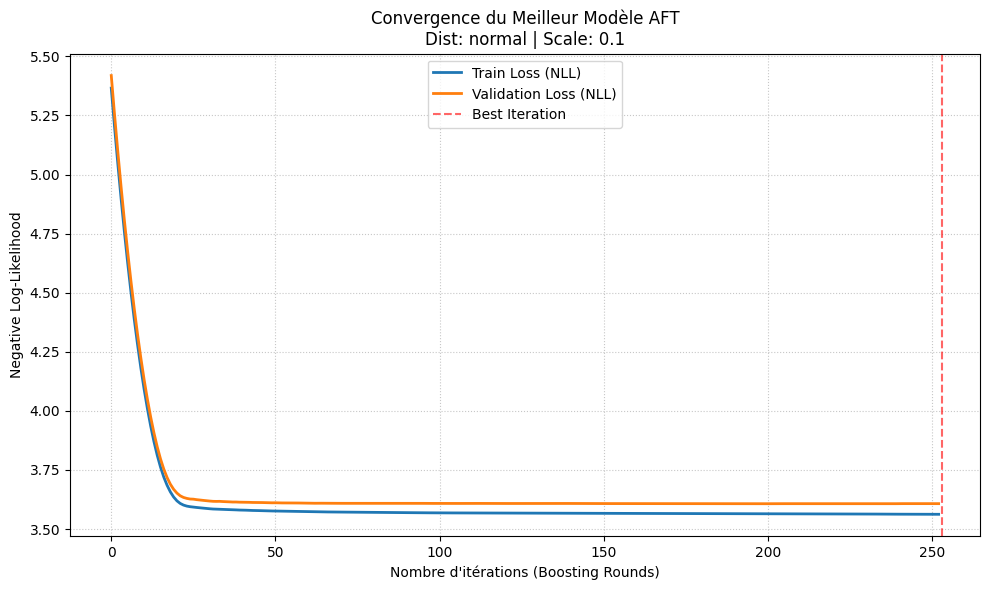

In [ ]:

# Variables pour le suivi du meilleur modèle
best_nloglik = float('inf')
best_params = None
best_history = {} 

print(f"Lancement du tuning sur {len(combinations)} combinaisons...")

for p in tqdm(combinations, desc="Tuning XGB AFT"):
    params = {
        'objective': 'survival:aft',
        'tree_method': 'hist',
        **p
    }
    
    # On crée un dictionnaire pour stocker les scores de cette itération
    evals_result = {}
    
    aft_model = xgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        evals=[(dtrain, 'train'), (dval, 'val')],
        early_stopping_rounds=50,
        evals_result=evals_result,
        verbose_eval=False 
    )
    
    current_score = aft_model.best_score
    
    if current_score < best_nloglik:
        best_nloglik = current_score
        best_params = p
        best_history = evals_result # On sauvegarde l'historique du record
        print(f" Nouveau Record ! Score: {best_nloglik:.4f} | Params: {p}")


# VISUALISATION DE LA COURBE D'APPRENTISSAGE 

plt.figure(figsize=(10, 6))
# 'aft-nloglik' est le nom par défaut de la métrique pour l'objectif survival:aft
train_loss = best_history['train']['aft-nloglik']
val_loss = best_history['val']['aft-nloglik']

plt.plot(train_loss, label='Train Loss (NLL)', color='#1f77b4', lw=2)
plt.plot(val_loss, label='Validation Loss (NLL)', color='#ff7f0e', lw=2)

# On marque l'endroit où l'Early Stopping a arrêté l'entraînement
plt.axvline(x=len(val_loss), color='red', linestyle='--', alpha=0.6, label='Best Iteration')

plt.title(f"Convergence du Meilleur Modèle AFT\nDist: {best_params['aft_loss_distribution']} | Scale: {best_params['aft_loss_distribution_scale']}", fontsize=12)
plt.xlabel("Nombre d'itérations (Boosting Rounds)")
plt.ylabel("Negative Log-Likelihood")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

In [300]:
# Concaténation train + val
df_trainval = pd.concat([df_train, df_val], ignore_index=True)
dtrainval = xgb.DMatrix(df_trainval[features_aft])
dtrainval.set_float_info('label_lower_bound', df_trainval['y_lower_log'].values)
dtrainval.set_float_info('label_upper_bound', df_trainval['y_upper_log'].values)

# Meilleurs paramètres trouvés
best_params_aft = best_params.copy()
best_params_aft['objective'] = 'survival:aft'
best_params_aft['tree_method'] = 'hist'

# Entraînement final
aft_final_model = xgb.train(
    best_params_aft,
    dtrainval,
    num_boost_round=1000,
    evals=[(dtrainval,'train')],
    early_stopping_rounds=50,
    verbose_eval=50
)

[0]	train-aft-nloglik:5.37084
[50]	train-aft-nloglik:3.58159
[100]	train-aft-nloglik:3.57297
[150]	train-aft-nloglik:3.57029
[200]	train-aft-nloglik:3.56837
[250]	train-aft-nloglik:3.56727
[300]	train-aft-nloglik:3.56607
[350]	train-aft-nloglik:3.56532
[400]	train-aft-nloglik:3.56516
[450]	train-aft-nloglik:3.56514
[500]	train-aft-nloglik:3.56511
[550]	train-aft-nloglik:3.56510
[600]	train-aft-nloglik:3.56509
[650]	train-aft-nloglik:3.56507
[700]	train-aft-nloglik:3.56506
[750]	train-aft-nloglik:3.56506
[800]	train-aft-nloglik:3.56505
[850]	train-aft-nloglik:3.56505
[900]	train-aft-nloglik:3.56504
[950]	train-aft-nloglik:3.56503
[999]	train-aft-nloglik:3.56503


In [301]:
# Prédiction AFT
df_trainval['pred_aft'] = aft_final_model.predict(dtrainval)
dtest = xgb.DMatrix(df_test[features_aft])
df_test['pred_aft'] = aft_final_model.predict(dtest)

In [302]:
y_true_real = np.expm1(df_test['y_lower_log'].values)

from lifelines.utils import concordance_index

c_index = concordance_index(
    event_times=y_true_real,        # durée réelle restante
    predicted_scores=df_test['pred_aft'],    
    event_observed=df_test['evt']    
)

print(f"C-index de validation : {c_index:.4f}")

C-index de validation : 0.7738


In [225]:
features_binary

['dist',
 'azi_sin',
 'azi_cos',
 'amplitude',
 'temps_inter_eclair',
 'vitesse_eloi',
 'dist_moy_5',
 'amp_moy_5',
 'saison_Automne',
 'saison_Hiver',
 'saison_Printemps',
 'saison_Été',
 'airport_Ajaccio',
 'airport_Bastia',
 'airport_Biarritz',
 'airport_Nantes',
 'airport_Pise',
 'pred_aft']

In [303]:
features_binary = features_aft + ['pred_aft']

features_bin = ['pred_aft', 'temps_inter_eclair', "dist", "amplitude"]
#features_binary.remove("duree_ecoulee")
X_trainval = df_trainval[features_binary]

y_trainval = df_trainval['evt'].astype(int)
X_test = df_test[features_binary]
y_test = df_test['evt'].astype(int) 


Tuning XGB Classifier:   8%|▊         | 1/12 [00:10<01:59, 10.86s/it]

 Nouveau record F1: 0.3171 avec {'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 500, 'subsample': 0.7, 'colsample_bytree': 0.7, 'gamma': 0}


Tuning XGB Classifier:  25%|██▌       | 3/12 [00:31<01:32, 10.24s/it]

 Nouveau record F1: 0.3391 avec {'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 500, 'subsample': 0.7, 'colsample_bytree': 0.7, 'gamma': 0}


Tuning XGB Classifier:  58%|█████▊    | 7/12 [01:10<00:49,  9.97s/it]

 Nouveau record F1: 0.3585 avec {'max_depth': 4, 'learning_rate': 0.05, 'n_estimators': 500, 'subsample': 0.7, 'colsample_bytree': 0.7, 'gamma': 0}


Tuning XGB Classifier:  92%|█████████▏| 11/12 [02:11<00:14, 14.43s/it]

 Nouveau record F1: 0.3780 avec {'max_depth': 6, 'learning_rate': 0.05, 'n_estimators': 500, 'subsample': 0.7, 'colsample_bytree': 0.7, 'gamma': 0}


Tuning XGB Classifier: 100%|██████████| 12/12 [02:23<00:00, 11.94s/it]


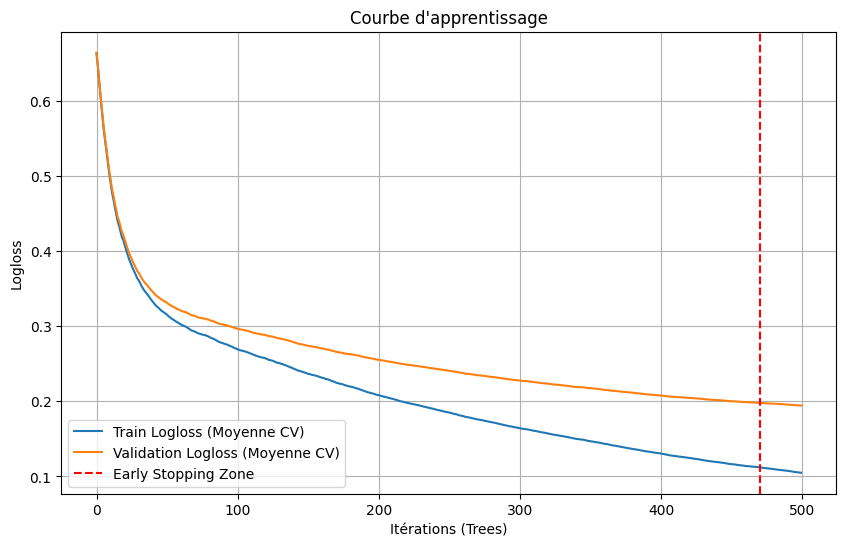

In [304]:
# Classifieur XGBOOST
from itertools import product
param_grid = {
    'max_depth': [3, 4, 6],
    'learning_rate': [0.01, 0.05],
    'n_estimators': [500],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7],
    'gamma': [0]
}

keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in product(*values)]



skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Initialisation pour stocker les courbes du meilleur modèle
best_f1 = 0
best_params = None
best_history = [] # Pour stocker les courbes de logloss du meilleur paramétrage

for p in tqdm(combinations, desc="Tuning XGB Classifier"):
    f1_scores = []
    current_params_histories = [] # Historique des 2 splits pour cette combinaison
    
    for train_idx, val_idx in skf.split(X_trainval, y_trainval):
        X_tr, X_va = X_trainval.iloc[train_idx], X_trainval.iloc[val_idx]
        y_tr, y_va = y_trainval.iloc[train_idx], y_trainval.iloc[val_idx]
        
        
        clf = XGBClassifier(
            **p,
            scale_pos_weight=(len(y_tr) - y_tr.sum()) / y_tr.sum(),
            eval_metric=['logloss'], 
            random_state=42,
            early_stopping_rounds=30
        )
        
        clf.fit(
            X_tr, y_tr,
            eval_set=[(X_tr, y_tr), (X_va, y_va)], 
            verbose=False
        )
        
        # On récupère l'historique de l'entraînement
        current_params_histories.append(clf.evals_result())
        
        y_pred = clf.predict(X_va)
        f1_scores.append(f1_score(y_va, y_pred))
    
    mean_f1 = np.mean(f1_scores)
    
    if mean_f1 > best_f1:
        best_f1 = mean_f1
        best_params = p
        best_history = current_params_histories
        print(f" Nouveau record F1: {best_f1:.4f} avec {best_params}")

# Visualisation de la courbe d'apprentissage du meilleur modèle

# Calcul de la moyenne des pertes sur les splits pour le meilleur modèle
train_loss_mean = np.mean([h['validation_0']['logloss'] for h in best_history], axis=0)
val_loss_mean = np.mean([h['validation_1']['logloss'] for h in best_history], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(train_loss_mean, label='Train Logloss (Moyenne CV)')
plt.plot(val_loss_mean, label='Validation Logloss (Moyenne CV)')
plt.axvline(x=len(val_loss_mean)-30, color='r', linestyle='--', label='Early Stopping Zone')
plt.title(f"Courbe d'apprentissage")
plt.xlabel('Itérations (Trees)')
plt.ylabel('Logloss')
plt.legend()
plt.grid(True)
plt.show()


In [305]:
print(f" Nouveau record F1: {best_f1:.4f} avec {best_params}")

 Nouveau record F1: 0.3780 avec {'max_depth': 6, 'learning_rate': 0.05, 'n_estimators': 500, 'subsample': 0.7, 'colsample_bytree': 0.7, 'gamma': 0}


In [306]:
X_trainval

,dist,azi_sin,azi_cos,amplitude,temps_inter_eclair,vitesse_eloi,dist_moy_5,amp_moy_5,heure_sin,heure_cos,...,saison_Automne,saison_Hiver,saison_Printemps,saison_Été,airport_Ajaccio,airport_Bastia,airport_Biarritz,airport_Nantes,airport_Pise,pred_aft
0,0.286598,0.406193,1.487475,0.116509,-0.449487,0.000973,0.398651,0.177801,-0.791727,1.218619,...,0,1,0,0,1,0,0,0,0,1.455052
1,0.356897,0.578460,1.395312,0.155270,0.135686,0.064220,0.447809,0.207684,-0.781686,1.226246,...,0,1,0,0,1,0,0,0,0,2.559284
2,0.454794,0.364178,1.504950,-0.308572,-0.069747,0.089050,0.509834,-0.020749,-0.776638,1.230028,...,0,1,0,0,1,0,0,0,0,2.750763
3,0.403580,0.762740,1.253224,0.009528,-0.113324,-0.045104,0.522939,-0.012349,-0.766491,1.237532,...,0,1,0,0,1,0,0,0,0,3.127501
4,0.875994,0.765105,1.251045,0.173359,0.120123,0.426002,0.662943,0.043212,-0.761390,1.241253,...,0,1,0,0,1,0,0,0,0,2.982664
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45878,0.299842,0.776057,1.240821,0.060951,1.595504,-0.178895,0.615818,-0.346452,0.340905,1.523019,...,0,0,1,0,0,0,0,0,1,2.850820
45879,0.878010,1.241946,-0.200393,-0.933401,6.513443,0.521148,0.793155,-0.701452,0.487636,1.498660,...,0,0,1,0,0,0,0,0,1,1.928844
45880,-1.170535,-0.273275,-1.447496,0.424789,2.311407,-1.842096,0.273263,-0.709023,0.537959,1.486997,...,0,0,1,0,0,0,0,0,1,2.643175
45881,0.303844,-1.056205,-0.957586,0.524276,5.971847,1.327466,0.224650,-0.604793,0.667671,1.448689,...,0,0,1,0,0,0,0,0,1,2.226536


In [307]:
# Calcul du scale_pos_weight pour déséquilibre
scale_pos_weight = (len(y_trainval) - y_trainval.sum()) / y_trainval.sum()

# Modèle final
clf_final = XGBClassifier(
    **best_params,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)

# Fit sur tout le train
clf_final.fit(X_trainval, y_trainval)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.7
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [308]:
# prédiction sur le test 
df_test['prob_lever'] = clf_final.predict_proba(X_test)[:,1]

In [309]:
df_test

,lightning_id,lightning_airport_id,date,lon,lat,amplitude,maxis,icloud,dist,azimuth,...,saison_Hiver,saison_Printemps,saison_Été,airport_Ajaccio,airport_Bastia,airport_Biarritz,airport_Nantes,airport_Pise,pred_aft,prob_lever
0,15177,15177,2018-05-14 13:46:33+00:00,8.8303,42.0778,0.156820,0.184,False,0.816721,10.075795,...,0,1,0,1,0,0,0,0,2.269548,0.927943
1,15179,15179,2018-05-14 14:04:45+00:00,8.8630,41.8842,0.187054,0.820,False,-1.453361,123.247809,...,0,1,0,1,0,0,0,0,2.650253,0.865885
2,15183,15183,2018-05-15 03:58:49+00:00,8.7587,41.7525,0.932560,0.235,False,1.259273,194.484472,...,0,1,0,1,0,0,0,0,1.864674,0.837598
3,15823,15823,2018-06-13 13:36:47+00:00,8.7955,42.1022,-0.747606,0.072,False,1.364447,357.627400,...,0,0,1,1,0,0,0,0,2.402496,0.885384
4,15824,15824,2018-06-13 13:39:06+00:00,8.8069,42.0972,-1.021002,0.110,False,1.244727,1.319946,...,0,0,1,1,0,0,0,0,3.743220,0.370793
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10711,474197,2189,2016-04-23 19:25:42+00:00,10.5166,43.7252,-0.026391,0.200,False,-0.729167,75.597508,...,0,1,0,0,0,0,0,1,2.362908,0.922496
10712,474200,2192,2016-04-23 19:32:21+00:00,10.5289,43.7277,0.558644,0.400,False,-0.511104,75.870390,...,0,1,0,0,0,0,0,1,3.193136,0.568614
10713,474791,2783,2016-04-24 02:53:09+00:00,10.2036,43.5922,0.500244,0.600,False,1.272989,242.251128,...,0,1,0,0,0,0,0,1,2.526295,0.897947
10714,472059,51,2016-01-12 23:22:46+00:00,10.2899,43.6800,0.746507,1.300,False,-0.963588,262.171568,...,1,0,0,0,0,0,0,1,1.524128,0.862740


In [318]:
SEUIL_FINAL = 0.9 # à ajuster
df_test['lever_alerte_final'] = df_test['prob_lever'] > SEUIL_FINAL
cm  = confusion_matrix(df_test['evt'], df_test['lever_alerte_final'])
print(cm)
print(classification_report(df_test['evt'], df_test['lever_alerte_final']))

[[10243    78]
 [  336    59]]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     10321
           1       0.43      0.15      0.22       395

    accuracy                           0.96     10716
   macro avg       0.70      0.57      0.60     10716
weighted avg       0.95      0.96      0.95     10716



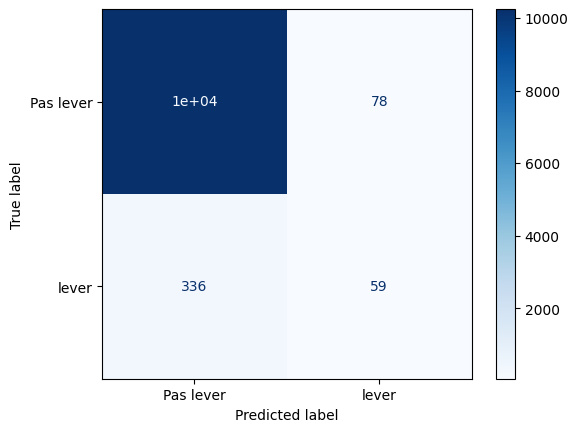

In [319]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Pas lever","lever"])
disp.plot(cmap='Blues')

In [320]:
# Calcul de l'AUC
auc_score = roc_auc_score(y_score=df_test['prob_lever'].values, y_true=df_test["evt"])
print(f"AUC: {auc_score:.4f}")

AUC: 0.9011


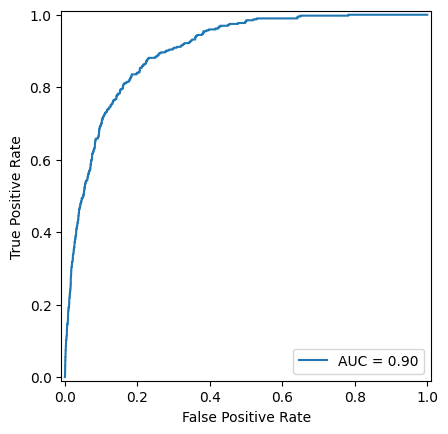

In [321]:
from sklearn.metrics import roc_curve, RocCurveDisplay
fpr, tpr, thresshold = roc_curve(y_score=df_test['prob_lever'].values, y_true=df_test["evt"])
roc = RocCurveDisplay(roc_auc= auc_score, fpr=fpr, tpr = tpr)
roc.plot()


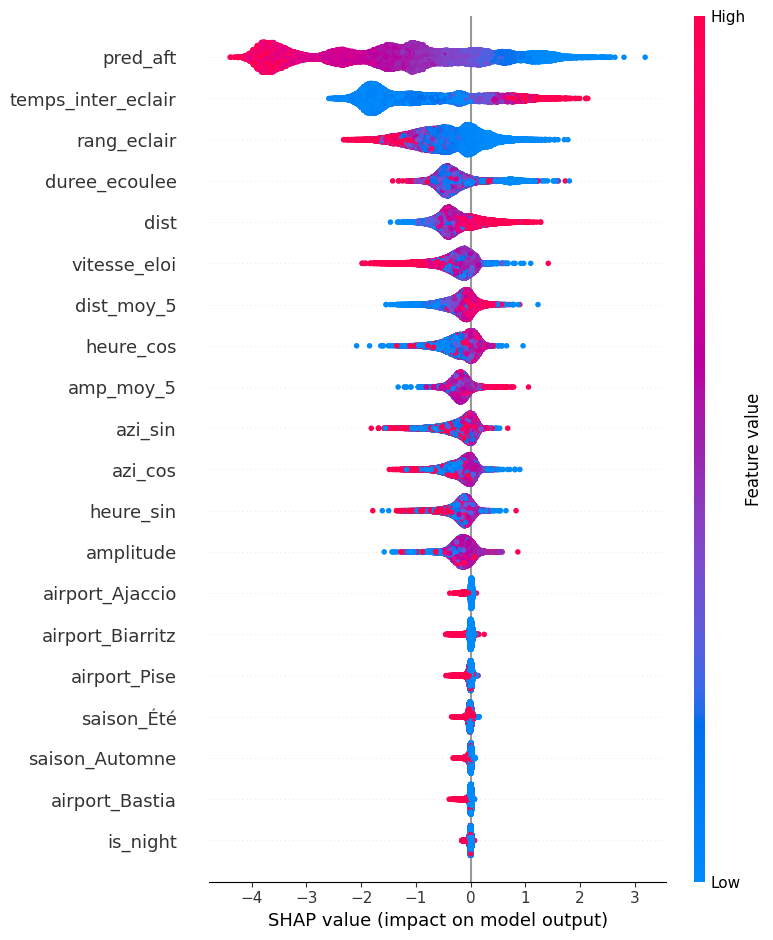

In [322]:
import shap
explainer = shap.TreeExplainer(clf_final)
shap_values = explainer.shap_values(X_trainval)

shap.summary_plot(shap_values, X_trainval)